# Spatial-scaling null models and revised Figure 2

This notebook reproduces the spatial-scaling robustness analyses used for the
revised Figure 2 of *Low-Dimensional Cortical Geometry Organizes Linguistic
Representations and Subcortical Updating Signals*.

It performs four complementary analyses:

1. reproduces the empirical cortical eigenmode spectrum and its primary
   power-law fit over modes 1–60;
2. compares the empirical spectrum with an analytical heat-kernel
   spatial-smoothing null and tests goodness of fit by parametric bootstrap;
3. validates the analytical null with explicit heat diffusion of random maps
   on the fsaverage5 cortical mesh;
4. compares power-law, exponential, stretched-exponential, and
   power-law-with-cutoff models at group and participant level, including
   alternative fitting ranges.

## Required local inputs

The notebook assumes the repository is located at
`~/eigenmode_fingerprints` and requires:

- `pang_out/group/energy_spectrum_group.csv`
- `pang_out/group/energy_spectrum_subject.csv`
- `modes/fsaverage5/phi_L.npy`, `phi_R.npy`, `lam_L.npy`, `lam_R.npy`
- `pang_surfaces/fsaverage5/lh.white.surf.gii`
- `pang_surfaces/fsaverage5/rh.white.surf.gii`

The explicit mesh simulation is used as a validation of the analytical
smooth-field null. Inferential testing uses the separate 10,000-realization
parametric bootstrap.

Run the notebook top-to-bottom from a fresh kernel. Intermediate and final
outputs are written under `pang_out/`.


In [1]:
# ============================================================
# SPATIAL SCALING NULL MODEL
# Surface heat-kernel analogue of Pang et al. (2023)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

BASE = Path.home() / "eigenmode_fingerprints"

OUT = (
    BASE
    / "pang_out"
    / "spatial_scaling_null_models"
)

OUT.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(20260831)

print("Output:", OUT)

Output: /home/whinzen/eigenmode_fingerprints/pang_out/spatial_scaling_null_models


In [2]:
# ============================================================
# Helper functions
# ============================================================

def normalize_spectrum(E):
    """
    Normalize modal energy to unit total power.
    """
    E = np.asarray(E, dtype=float)
    return E / np.sum(E)


def fit_powerlaw(lam, E, mode_start=1, mode_stop=60):
    """
    Fit log10(E) = intercept + alpha * log10(lambda)

    mode_start and mode_stop refer to retained-mode numbering,
    assuming mode 0/global has already been removed.
    Example: 1..60 -> Python slice 0:60.
    """
    lam = np.asarray(lam)
    E = np.asarray(E)

    idx = np.arange(len(lam))

    keep = (
        (idx >= mode_start - 1)
        & (idx <= mode_stop - 1)
        & np.isfinite(lam)
        & np.isfinite(E)
        & (lam > 0)
        & (E > 0)
    )

    x = np.log10(lam[keep])
    y = np.log10(E[keep])

    slope, intercept, r, p, se = stats.linregress(x, y)

    return {
        "alpha": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "se": se,
        "n_modes": keep.sum(),
    }


def log_spectral_mse(E1, E2, eps=1e-15):
    """
    Pang-like mean squared logarithmic spectral error.

    Spectra are normalized first.
    """
    p1 = normalize_spectrum(E1)
    p2 = normalize_spectrum(E2)

    return np.mean(
        (
            np.log10(p1 + eps)
            - np.log10(p2 + eps)
        )**2
    )


def fwhm_to_tau(fwhm_mm):
    """
    Surface heat-kernel parameter corresponding approximately
    to Gaussian smoothing with given FWHM in mm.

    tau = sigma^2 / 2
    FWHM = 2 sqrt(2 ln2) sigma
    """
    return (fwhm_mm**2) / (16.0 * np.log(2.0))

## 1. Empirical spectrum and Figure 2 fit


In [3]:
# ============================================================
# LOAD THE EXACT EMPIRICAL SPECTRUM USED FOR FIGURE 2
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path.home() / "eigenmode_fingerprints"

EMP_FILE = (
    BASE
    / "pang_out"
    / "group"
    / "energy_spectrum_group.csv"
)

emp = pd.read_csv(EMP_FILE)

print("File:", EMP_FILE)
print("Shape:", emp.shape)
print("Columns:", emp.columns.tolist())

display(emp.head(10))

# Exact variables used by current Figure 2
lam_emp = emp["lam"].to_numpy(float)
energy_emp = emp["Emean"].to_numpy(float)
energy_sem = emp["Esem"].to_numpy(float)
mode_k = emp["mode_k"].to_numpy(int)

print("\nMode range:", mode_k.min(), "to", mode_k.max())
print("Number of modes:", len(mode_k))

# Figure-2 fitting interval
fit_mask = (
    (mode_k >= 1)
    & (mode_k <= 60)
    & (lam_emp > 0)
    & (energy_emp > 0)
)

x = np.log10(lam_emp[fit_mask])
y = np.log10(energy_emp[fit_mask])

from scipy.stats import linregress

fit = linregress(x, y)

print("\nREPRODUCED FIGURE-2 FIT")
print("-----------------------")
print(f"slope alpha = {fit.slope:.6f}")
print(f"R²          = {fit.rvalue**2:.6f}")
print(f"p           = {fit.pvalue:.6g}")
print(f"SE slope    = {fit.stderr:.6f}")
print(f"n modes     = {fit_mask.sum()}")

File: /home/whinzen/eigenmode_fingerprints/pang_out/group/energy_spectrum_group.csv
Shape: (120, 4)
Columns: ['mode_k', 'lam', 'Emean', 'Esem']


,mode_k,lam,Emean,Esem
0,0,1.583248e-08,1097.957349,7.669967
1,1,2.292283e-04,8.508433,0.726815
2,2,4.418148e-04,22.601893,0.760852
3,3,5.036462e-04,73.886160,0.488700
4,4,7.804139e-04,8.314994,0.201228
5,5,9.679925e-04,2.843803,0.279457
6,6,1.079500e-03,11.805070,0.115284
7,7,1.469112e-03,3.878564,0.258019
8,8,1.516375e-03,11.900979,0.105420
9,9,1.750172e-03,3.506677,0.144366



Mode range: 0 to 119
Number of modes: 120

REPRODUCED FIGURE-2 FIT
-----------------------
slope alpha = -1.001475
R²          = 0.736715
p           = 1.88157e-18
SE slope    = 0.078612
n modes     = 60


### Subject-level validation


In [6]:
# ============================================================
# VALIDATE SUBJECT-LEVEL SPECTRA AGAINST FIGURE-2 GROUP SPECTRUM
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path.home() / "eigenmode_fingerprints"
GRP = BASE / "pang_out" / "group"

SUB_FILE = GRP / "energy_spectrum_subject.csv"
GROUP_FILE = GRP / "energy_spectrum_group.csv"

sub = pd.read_csv(SUB_FILE)
grp = pd.read_csv(GROUP_FILE)

print("SUBJECT FILE")
print("------------")
print("File:", SUB_FILE)
print("Shape:", sub.shape)
print("Columns:", sub.columns.tolist())
display(sub.head(10))

print("\nGROUP FILE")
print("----------")
print("Shape:", grp.shape)
print("Columns:", grp.columns.tolist())
display(grp.head(10))

print("\nUnique subjects:", sub["subject"].nunique() if "subject" in sub.columns else "NO subject COLUMN")
print("Mode range:", sub["mode_k"].min(), "to", sub["mode_k"].max())

SUBJECT FILE
------------
File: /home/whinzen/eigenmode_fingerprints/pang_out/group/energy_spectrum_subject.csv
Shape: (5880, 4)
Columns: ['subject', 'mode_k', 'lam', 'Emean']


,subject,mode_k,lam,Emean
0,sub-EN057,0,1.583248e-08,1094.866109
1,sub-EN057,1,2.292283e-04,7.883918
2,sub-EN057,2,4.418148e-04,27.392452
3,sub-EN057,3,5.036462e-04,76.785873
4,sub-EN057,4,7.804139e-04,7.856493
5,sub-EN057,5,9.679925e-04,2.930757
6,sub-EN057,6,1.079500e-03,10.664473
7,sub-EN057,7,1.469112e-03,3.264242
8,sub-EN057,8,1.516375e-03,12.184275
9,sub-EN057,9,1.750172e-03,2.901955



GROUP FILE
----------
Shape: (120, 4)
Columns: ['mode_k', 'lam', 'Emean', 'Esem']


,mode_k,lam,Emean,Esem
0,0,1.583248e-08,1097.957349,7.669967
1,1,2.292283e-04,8.508433,0.726815
2,2,4.418148e-04,22.601893,0.760852
3,3,5.036462e-04,73.886160,0.488700
4,4,7.804139e-04,8.314994,0.201228
5,5,9.679925e-04,2.843803,0.279457
6,6,1.079500e-03,11.805070,0.115284
7,7,1.469112e-03,3.878564,0.258019
8,8,1.516375e-03,11.900979,0.105420
9,9,1.750172e-03,3.506677,0.144366



Unique subjects: 49
Mode range: 0 to 119


In [7]:
# ============================================================
# CHECK THAT SUBJECT-LEVEL AVERAGING REPRODUCES GROUP FIGURE 2
# ============================================================

# Identify the subject-level energy column
candidate_energy_cols = [
    c for c in sub.columns
    if c.lower() in ["e", "emean", "energy", "mean_energy"]
]

print("Candidate subject energy columns:", candidate_energy_cols)

# Most likely this will be Emean.
ENERGY_COL = candidate_energy_cols[0]

reconstructed = (
    sub.groupby("mode_k", as_index=False)
       .agg(
           lam=("lam", "mean"),
           Emean_reconstructed=(ENERGY_COL, "mean"),
           Esem_reconstructed=(ENERGY_COL, "sem")
       )
)

check = grp.merge(
    reconstructed,
    on="mode_k",
    suffixes=("_stored", "_reconstructed")
)

check["abs_diff_Emean"] = np.abs(
    check["Emean"] - check["Emean_reconstructed"]
)

check["rel_diff_Emean"] = (
    check["abs_diff_Emean"]
    / np.maximum(np.abs(check["Emean"]), 1e-15)
)

print("Maximum absolute difference in Emean:",
      check["abs_diff_Emean"].max())

print("Maximum relative difference in Emean:",
      check["rel_diff_Emean"].max())

print("\nStored vs reconstructed:")
display(
    check[
        [
            "mode_k",
            "Emean",
            "Emean_reconstructed",
            "Esem",
            "Esem_reconstructed",
            "abs_diff_Emean"
        ]
    ].head(15)
)

Candidate subject energy columns: ['Emean']
Maximum absolute difference in Emean: 1.7763568394002505e-15
Maximum relative difference in Emean: 3.3899013878768476e-16

Stored vs reconstructed:


,mode_k,Emean,Emean_reconstructed,Esem,Esem_reconstructed,abs_diff_Emean
0,0,1097.957349,1097.957349,7.669967,7.669967,0.000000e+00
1,1,8.508433,8.508433,0.726815,0.726815,0.000000e+00
2,2,22.601893,22.601893,0.760852,0.760852,0.000000e+00
3,3,73.886160,73.886160,0.488700,0.488700,0.000000e+00
4,4,8.314994,8.314994,0.201228,0.201228,0.000000e+00
5,5,2.843803,2.843803,0.279457,0.279457,0.000000e+00
6,6,11.805070,11.805070,0.115284,0.115284,1.776357e-15
7,7,3.878564,3.878564,0.258019,0.258019,4.440892e-16
8,8,11.900979,11.900979,0.105420,0.105420,0.000000e+00
9,9,3.506677,3.506677,0.144366,0.144366,0.000000e+00


## 2. Analytical spatial-smoothing null


In [8]:
# ============================================================
# SPATIAL-SMOOTHNESS NULL — PANG-STYLE SURFACE VERSION
#
# Empirical hierarchy:
#   49 subjects -> group mean spectrum
#
# Null:
#   spatial white noise
#       -> heat-kernel smoothing on cortical geometry
#       -> geometric eigenmode spectrum
#
# We scan FWHM = 0...50 mm and ask:
#   Which amount of generic spatial smoothing most closely
#   reproduces the empirical spectrum?
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = Path.home() / "eigenmode_fingerprints"
GRP = BASE / "pang_out" / "group"

OUT = (
    BASE
    / "pang_out"
    / "spatial_smoothing_null"
)
OUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load exact empirical Figure-2 spectrum
# ------------------------------------------------------------

grp = pd.read_csv(
    GRP / "energy_spectrum_group.csv"
)

mode = grp["mode_k"].to_numpy(int)
lam = grp["lam"].to_numpy(float)
E_emp = grp["Emean"].to_numpy(float)

# Exclude constant/global mode 0
keep = mode >= 1

mode1 = mode[keep]
lam1 = lam[keep]
E_emp1 = E_emp[keep]

# Manuscript Figure-2 fitting range
fit60 = (
    (mode1 >= 1)
    & (mode1 <= 60)
)

print("Modes used for whole-spectrum comparison:",
      mode1.min(), "to", mode1.max())

print("Modes used for power-law fit:",
      mode1[fit60].min(), "to", mode1[fit60].max())

Modes used for whole-spectrum comparison: 1 to 119
Modes used for power-law fit: 1 to 60


In [9]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_energy(E):
    """Normalize spectrum to sum to 1."""
    E = np.asarray(E, dtype=float)
    return E / np.sum(E)


def fwhm_to_tau(fwhm_mm):
    """
    Heat-kernel diffusion parameter corresponding approximately
    to a Gaussian smoothing kernel with the requested FWHM.

    For Gaussian kernel:
        sigma = FWHM / sqrt(8 ln 2)

    Heat kernel:
        exp(-tau * lambda)

    with:
        tau = sigma^2 / 2
            = FWHM^2 / (16 ln 2)

    Assumes surface coordinates / eigenvalues are expressed
    consistently with millimetres.
    """
    return (fwhm_mm ** 2) / (16.0 * np.log(2.0))


def powerlaw_fit(lam, E):
    """
    log10(E) = intercept + alpha * log10(lambda)
    """
    x = np.log10(lam)
    y = np.log10(E)

    res = stats.linregress(x, y)

    return {
        "alpha": res.slope,
        "intercept": res.intercept,
        "r2": res.rvalue**2,
        "p": res.pvalue,
        "se": res.stderr
    }


def log_spectral_mse(Ea, Eb):
    """
    Mean squared error between normalized spectra in log10 space.
    Conceptually analogous to Pang et al.'s logarithmic
    spectral-distance analysis.
    """
    pa = normalize_energy(Ea)
    pb = normalize_energy(Eb)

    eps = 1e-15

    return np.mean(
        (
            np.log10(pa + eps)
            - np.log10(pb + eps)
        ) ** 2
    )


def quadratic_log_curvature(lam, E):
    """
    Fit:
       log10(E) =
           b0 + b1*log10(lambda) + b2*log10(lambda)^2

    b2 is a simple measure of curvature away from a straight
    power law in log-log coordinates.
    """
    x = np.log10(lam)
    y = np.log10(E)

    X = np.column_stack([
        np.ones_like(x),
        x,
        x**2
    ])

    beta, *_ = np.linalg.lstsq(
        X, y, rcond=None
    )

    yhat = X @ beta

    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)

    r2 = 1 - ss_res / ss_tot

    return {
        "intercept": beta[0],
        "linear": beta[1],
        "quadratic": beta[2],
        "r2_quadratic": r2
    }

In [10]:
# ============================================================
# EMPIRICAL FIGURE-2 STATISTICS
# ============================================================

emp_pl = powerlaw_fit(
    lam1[fit60],
    E_emp1[fit60]
)

emp_curve = quadratic_log_curvature(
    lam1[fit60],
    E_emp1[fit60]
)

print("EMPIRICAL FIGURE-2 SPECTRUM")
print("---------------------------")
print(f"alpha      = {emp_pl['alpha']:.6f}")
print(f"R²         = {emp_pl['r2']:.6f}")
print(f"p          = {emp_pl['p']:.3e}")
print(f"quadratic  = {emp_curve['quadratic']:.6f}")

EMPIRICAL FIGURE-2 SPECTRUM
---------------------------
alpha      = -1.001475
R²         = 0.736715
p          = 1.882e-18
quadratic  = -0.187070


In [11]:
# ============================================================
# EXPECTED SPATIALLY-SMOOTH RANDOM-FIELD SPECTRA
# ============================================================

FWHM_GRID = np.arange(
    0.0,
    50.0 + 0.5,
    0.5
)

rows = []

for fwhm in FWHM_GRID:

    tau = fwhm_to_tau(fwhm)

    # Expected energy after heat-kernel smoothing
    E_null = np.exp(
        -2.0 * tau * lam1
    )

    # Whole spectrum: modes 1-119
    distance = log_spectral_mse(
        E_emp1,
        E_null
    )

    # Exact Figure-2 range: modes 1-60
    null_pl = powerlaw_fit(
        lam1[fit60],
        E_null[fit60]
    )

    null_curve = quadratic_log_curvature(
        lam1[fit60],
        E_null[fit60]
    )

    rows.append({
        "fwhm_mm": fwhm,
        "tau": tau,
        "spectral_log_mse_1_119": distance,
        "alpha_1_60": null_pl["alpha"],
        "powerlaw_r2_1_60": null_pl["r2"],
        "quadratic_1_60": null_curve["quadratic"]
    })

smooth = pd.DataFrame(rows)

smooth.to_csv(
    OUT / "expected_smoothing_spectra_grid.csv",
    index=False
)

best_idx = smooth[
    "spectral_log_mse_1_119"
].idxmin()

best = smooth.loc[best_idx]

print("\nBEST-FITTING GENERIC SMOOTHNESS")
print("--------------------------------")
print(best)


BEST-FITTING GENERIC SMOOTHNESS
--------------------------------
fwhm_mm                   31.000000
tau                       86.651871
spectral_log_mse_1_119     0.100237
alpha_1_60                -0.587816
powerlaw_r2_1_60           0.829643
quadratic_1_60            -0.522602
Name: 62, dtype: float64


/tmp/ipykernel_1586216/4060755505.py:96: RuntimeWarning: invalid value encountered in scalar divide
  r2 = 1 - ss_res / ss_tot


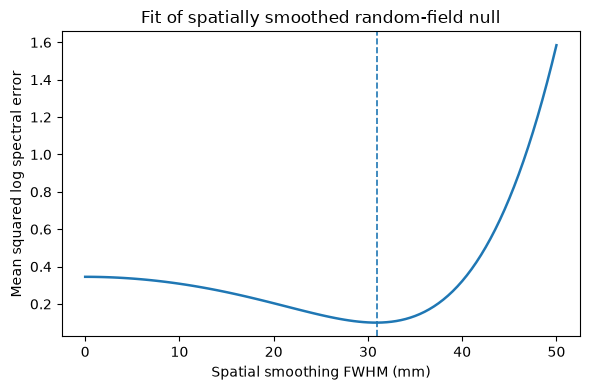

In [12]:
# ============================================================
# FIGURE A — SPECTRAL DISTANCE vs SMOOTHING
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    smooth["fwhm_mm"],
    smooth["spectral_log_mse_1_119"],
    lw=1.8
)

ax.axvline(
    best["fwhm_mm"],
    linestyle="--",
    lw=1.2
)

ax.set_xlabel("Spatial smoothing FWHM (mm)")
ax.set_ylabel("Mean squared log spectral error")

ax.set_title(
    "Fit of spatially smoothed random-field null"
)

plt.tight_layout()

fig.savefig(
    OUT / "null_spectral_error_by_fwhm.png",
    dpi=300
)

fig.savefig(
    OUT / "null_spectral_error_by_fwhm.pdf"
)

plt.show()

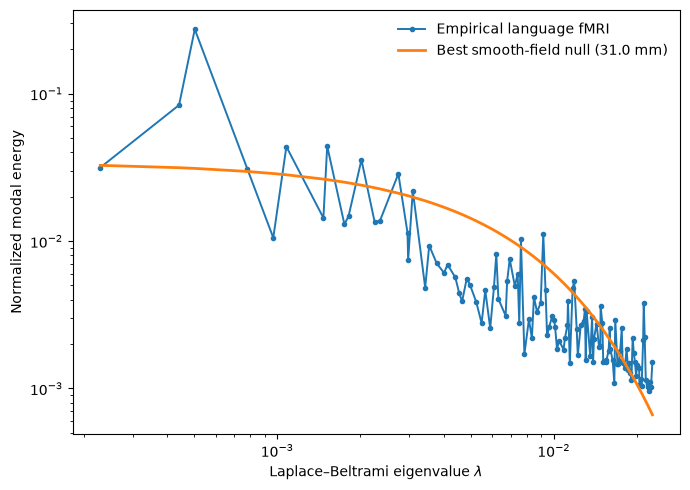

In [13]:
# ============================================================
# FIGURE B — EMPIRICAL vs BEST SMOOTHING NULL
# ============================================================

best_fwhm = float(best["fwhm_mm"])
best_tau = fwhm_to_tau(best_fwhm)

E_best = np.exp(
    -2.0 * best_tau * lam1
)

p_emp = normalize_energy(E_emp1)
p_best = normalize_energy(E_best)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    lam1,
    p_emp,
    marker="o",
    markersize=3,
    lw=1.4,
    label="Empirical language fMRI"
)

ax.plot(
    lam1,
    p_best,
    lw=2,
    label=f"Best smooth-field null ({best_fwhm:.1f} mm)"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Laplace–Beltrami eigenvalue $\lambda$")
ax.set_ylabel("Normalized modal energy")

ax.legend(
    frameon=False
)

plt.tight_layout()

fig.savefig(
    OUT / "empirical_vs_best_smoothing_null.png",
    dpi=300
)

fig.savefig(
    OUT / "empirical_vs_best_smoothing_null.pdf"
)

plt.show()

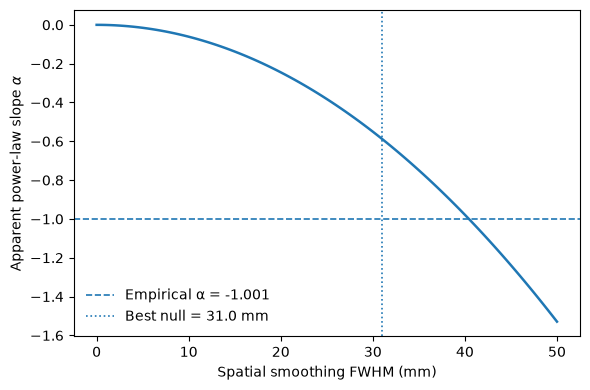

In [14]:
# ============================================================
# HOW DOES APPARENT POWER-LAW BEHAVIOUR CHANGE WITH SMOOTHING?
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    smooth["fwhm_mm"],
    smooth["alpha_1_60"],
    lw=1.8
)

ax.axhline(
    emp_pl["alpha"],
    linestyle="--",
    lw=1.2,
    label=f"Empirical α = {emp_pl['alpha']:.3f}"
)

ax.axvline(
    best_fwhm,
    linestyle=":",
    lw=1.2,
    label=f"Best null = {best_fwhm:.1f} mm"
)

ax.set_xlabel("Spatial smoothing FWHM (mm)")
ax.set_ylabel(r"Apparent power-law slope $\alpha$")

ax.legend(frameon=False)

plt.tight_layout()

fig.savefig(
    OUT / "null_alpha_by_fwhm.png",
    dpi=300
)

plt.show()

## 3. Candidate spectral models


In [15]:
# ============================================================
# COMPETING SPECTRAL MODELS — MODES 1–60
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

BASE = Path.home() / "eigenmode_fingerprints"
GRP = BASE / "pang_out" / "group"
OUT = BASE / "pang_out" / "spectral_model_comparison"
OUT.mkdir(parents=True, exist_ok=True)

grp = pd.read_csv(GRP / "energy_spectrum_group.csv")

d = grp[
    (grp["mode_k"] >= 1)
    & (grp["mode_k"] <= 60)
    & (grp["lam"] > 0)
    & (grp["Emean"] > 0)
].copy()

lam = d["lam"].to_numpy(float)
E = d["Emean"].to_numpy(float)

x = np.log(lam)
y = np.log(E)

n = len(y)

# ------------------------------------------------------------
# Information criteria
# ------------------------------------------------------------

def ic_from_residuals(y, yhat, k):
    resid = y - yhat
    rss = np.sum(resid**2)

    # Gaussian likelihood with estimated residual variance
    aic = n * np.log(rss / n) + 2 * k

    if n - k - 1 > 0:
        aicc = aic + (2 * k * (k + 1)) / (n - k - 1)
    else:
        aicc = np.nan

    bic = n * np.log(rss / n) + k * np.log(n)

    r2 = 1 - rss / np.sum((y - np.mean(y))**2)

    return rss, aic, aicc, bic, r2


results = []
predictions = {}

# ============================================================
# MODEL 1: POWER LAW
#
# E = C * lambda^alpha
# logE = c + alpha log(lambda)
# ============================================================

X = np.column_stack([np.ones(n), x])

beta, *_ = np.linalg.lstsq(X, y, rcond=None)

c_pl, alpha = beta
yhat_pl = X @ beta

rss, aic, aicc, bic, r2 = ic_from_residuals(
    y, yhat_pl, k=2
)

results.append({
    "model": "Power law",
    "k": 2,
    "alpha": alpha,
    "b": np.nan,
    "gamma": np.nan,
    "lambda_c": np.nan,
    "RSS_log": rss,
    "R2_log": r2,
    "AIC": aic,
    "AICc": aicc,
    "BIC": bic
})

predictions["Power law"] = np.exp(yhat_pl)


# ============================================================
# MODEL 2: EXPONENTIAL
#
# E = C * exp(-b lambda)
# logE = c - b lambda
# ============================================================

X = np.column_stack([np.ones(n), lam])

beta, *_ = np.linalg.lstsq(X, y, rcond=None)

c_exp = beta[0]
b_exp = -beta[1]

yhat_exp = X @ beta

rss, aic, aicc, bic, r2 = ic_from_residuals(
    y, yhat_exp, k=2
)

results.append({
    "model": "Exponential",
    "k": 2,
    "alpha": np.nan,
    "b": b_exp,
    "gamma": 1.0,
    "lambda_c": np.nan,
    "RSS_log": rss,
    "R2_log": r2,
    "AIC": aic,
    "AICc": aicc,
    "BIC": bic
})

predictions["Exponential"] = np.exp(yhat_exp)


# ============================================================
# MODEL 3: STRETCHED EXPONENTIAL
#
# E = C * exp(-b lambda^gamma)
# logE = c - b lambda^gamma
# ============================================================

def stretched_log(lam, c, b, gamma):
    return c - b * lam**gamma

p0 = [
    np.max(y),
    100.0,
    0.5
]

bounds = (
    [-np.inf, 0.0, 0.05],
    [ np.inf, np.inf, 5.0]
)

pars, _ = curve_fit(
    stretched_log,
    lam,
    y,
    p0=p0,
    bounds=bounds,
    maxfev=100000
)

c_str, b_str, gamma_str = pars

yhat_str = stretched_log(
    lam,
    *pars
)

rss, aic, aicc, bic, r2 = ic_from_residuals(
    y, yhat_str, k=3
)

results.append({
    "model": "Stretched exponential",
    "k": 3,
    "alpha": np.nan,
    "b": b_str,
    "gamma": gamma_str,
    "lambda_c": np.nan,
    "RSS_log": rss,
    "R2_log": r2,
    "AIC": aic,
    "AICc": aicc,
    "BIC": bic
})

predictions["Stretched exponential"] = np.exp(yhat_str)


# ============================================================
# MODEL 4: POWER LAW WITH EXPONENTIAL CUTOFF
#
# E = C * lambda^alpha * exp(-lambda/lambda_c)
#
# logE = c + alpha log(lambda) - lambda/lambda_c
# ============================================================

def cutoff_log(lam, c, alpha, inv_lambda_c):
    return (
        c
        + alpha * np.log(lam)
        - inv_lambda_c * lam
    )

p0 = [
    np.mean(y),
    -1.0,
    10.0
]

bounds = (
    [-np.inf, -10.0, 0.0],
    [ np.inf,  10.0, np.inf]
)

pars, _ = curve_fit(
    cutoff_log,
    lam,
    y,
    p0=p0,
    bounds=bounds,
    maxfev=100000
)

c_cut, alpha_cut, inv_lambda_c = pars

lambda_c = (
    np.inf
    if inv_lambda_c <= 1e-12
    else 1.0 / inv_lambda_c
)

yhat_cut = cutoff_log(
    lam,
    *pars
)

rss, aic, aicc, bic, r2 = ic_from_residuals(
    y, yhat_cut, k=3
)

results.append({
    "model": "Power law + cutoff",
    "k": 3,
    "alpha": alpha_cut,
    "b": np.nan,
    "gamma": np.nan,
    "lambda_c": lambda_c,
    "RSS_log": rss,
    "R2_log": r2,
    "AIC": aic,
    "AICc": aicc,
    "BIC": bic
})

predictions["Power law + cutoff"] = np.exp(yhat_cut)


# ============================================================
# SUMMARY
# ============================================================

res = pd.DataFrame(results)

res["delta_AICc"] = (
    res["AICc"] - res["AICc"].min()
)

res["delta_BIC"] = (
    res["BIC"] - res["BIC"].min()
)

# Akaike weights
w = np.exp(-0.5 * res["delta_AICc"])
res["Akaike_weight"] = w / np.sum(w)

res = res.sort_values(
    "AICc"
).reset_index(drop=True)

print("\nCOMPETING SPECTRAL MODELS — MODES 1–60")
print("---------------------------------------")

display(
    res[
        [
            "model",
            "R2_log",
            "AICc",
            "delta_AICc",
            "Akaike_weight",
            "BIC",
            "delta_BIC",
            "alpha",
            "b",
            "gamma",
            "lambda_c"
        ]
    ]
)

res.to_csv(
    OUT / "spectral_model_comparison_modes1_60.csv",
    index=False
)


COMPETING SPECTRAL MODELS — MODES 1–60
---------------------------------------


,model,R2_log,AICc,delta_AICc,Akaike_weight,BIC,delta_BIC,alpha,b,gamma,lambda_c
0,Power law,0.736715,-73.047891,0.000000,0.505268,-69.069728,0.000000,-1.001475,NaN,NaN,NaN
1,Stretched exponential,0.741747,-71.987717,1.060174,0.297377,-66.133255,2.936473,NaN,16.528294,0.138135,NaN
2,Power law + cutoff,0.738192,-71.167400,1.880491,0.197323,-65.312938,3.756791,-0.902516,NaN,NaN,0.034275
3,Exponential,0.636265,-53.656562,19.391329,0.000031,-49.678399,19.391329,NaN,249.931706,1.000000,NaN


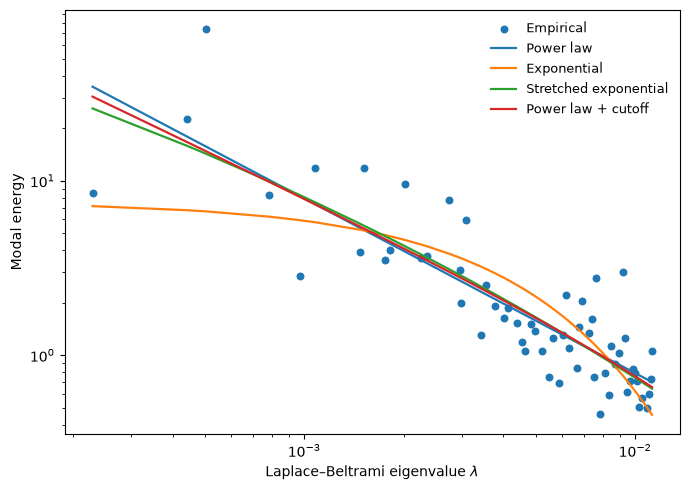

In [16]:
# ============================================================
# PLOT COMPETING MODELS
# ============================================================

import matplotlib.pyplot as plt

order = np.argsort(lam)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    lam,
    E,
    s=22,
    label="Empirical"
)

for name, pred in predictions.items():
    ax.plot(
        lam[order],
        pred[order],
        lw=1.6,
        label=name
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    r"Laplace–Beltrami eigenvalue $\lambda$"
)

ax.set_ylabel(
    "Modal energy"
)

ax.legend(
    frameon=False,
    fontsize=9
)

plt.tight_layout()

fig.savefig(
    OUT / "spectral_model_comparison_modes1_60.png",
    dpi=300
)

fig.savefig(
    OUT / "spectral_model_comparison_modes1_60.pdf"
)

plt.show()

## 4. Parametric-bootstrap goodness-of-fit test


In [17]:
# ============================================================
# PARAMETRIC BOOTSTRAP:
# GOODNESS-OF-FIT OF THE SMOOTH-RANDOM-FIELD FAMILY
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.home() / "eigenmode_fingerprints"
GRP = BASE / "pang_out" / "group"
OUT = BASE / "pang_out" / "spatial_smoothing_null"
OUT.mkdir(parents=True, exist_ok=True)

grp = pd.read_csv(
    GRP / "energy_spectrum_group.csv"
)

sub = pd.read_csv(
    GRP / "energy_spectrum_subject.csv"
)

N_SUBJECTS = sub["subject"].nunique()

mode = grp["mode_k"].to_numpy(int)
lam = grp["lam"].to_numpy(float)
E_emp = grp["Emean"].to_numpy(float)

keep = mode >= 1

mode1 = mode[keep]
lam1 = lam[keep]
E_emp1 = E_emp[keep]

fit60 = (
    (mode1 >= 1)
    & (mode1 <= 60)
)

print("N subjects:", N_SUBJECTS)
print("N modes:", len(mode1))

N subjects: 49
N modes: 119


In [18]:
def normalize_energy(E):
    E = np.asarray(E, float)
    return E / np.sum(E)


def fwhm_to_tau(fwhm_mm):
    return (
        fwhm_mm**2
        / (16.0 * np.log(2.0))
    )


def log_spectral_mse(Ea, Eb):
    pa = normalize_energy(Ea)
    pb = normalize_energy(Eb)

    eps = 1e-15

    return np.mean(
        (
            np.log10(pa + eps)
            - np.log10(pb + eps)
        )**2
    )


def powerlaw_stats(lam, E):
    x = np.log10(lam)
    y = np.log10(E)

    beta = np.polyfit(x, y, 1)

    yhat = np.polyval(beta, x)

    ss_res = np.sum(
        (y - yhat)**2
    )

    ss_tot = np.sum(
        (y - np.mean(y))**2
    )

    return {
        "alpha": beta[0],
        "r2": 1 - ss_res / ss_tot
    }


def quadratic_curvature(lam, E):
    x = np.log10(lam)
    y = np.log10(E)

    beta = np.polyfit(
        x,
        y,
        2
    )

    return beta[0]

In [19]:
# ============================================================
# SMOOTH-FIELD FAMILY
# ============================================================

FWHM_GRID = np.arange(
    0.0,
    50.0 + 0.5,
    0.5
)

taus = np.array([
    fwhm_to_tau(f)
    for f in FWHM_GRID
])

# rows = FWHM values
# columns = modes
family = np.exp(
    -2.0
    * taus[:, None]
    * lam1[None, :]
)

family_norm = (
    family
    / family.sum(
        axis=1,
        keepdims=True
    )
)

emp_norm = normalize_energy(
    E_emp1
)

eps = 1e-15

emp_distances = np.mean(
    (
        np.log10(
            family_norm + eps
        )
        - np.log10(
            emp_norm[None, :] + eps
        )
    )**2,
    axis=1
)

obs_best_idx = np.argmin(
    emp_distances
)

OBS_BEST_FWHM = (
    FWHM_GRID[obs_best_idx]
)

OBS_T = (
    emp_distances[obs_best_idx]
)

OBS_TAU = (
    taus[obs_best_idx]
)

print("OBSERVED")
print("--------")
print(
    f"Best FWHM = {OBS_BEST_FWHM:.2f}"
)

print(
    f"Minimum log spectral MSE = {OBS_T:.6f}"
)

OBSERVED
--------
Best FWHM = 31.00
Minimum log spectral MSE = 0.100237


In [20]:
# ============================================================
# PARAMETRIC BOOTSTRAP
# ============================================================

N_BOOT = 10000
SEED = 20260831

rng = np.random.default_rng(
    SEED
)

boot_rows = []

# Under the fitted null:
# expected modal energy:
expected_E = np.exp(
    -2.0
    * OBS_TAU
    * lam1
)

# corresponding amplitude SD:
amp_sd = np.sqrt(
    expected_E
)

for b in range(N_BOOT):

    # ----------------------------------------
    # Generate one random spectrum per subject
    # ----------------------------------------

    A = rng.normal(
        loc=0.0,
        scale=amp_sd[None, :],
        size=(
            N_SUBJECTS,
            len(lam1)
        )
    )

    # Modal energy for each subject
    E_sub_null = A**2

    # Exact analogue of empirical group averaging
    E_group_null = (
        E_sub_null.mean(axis=0)
    )

    null_norm = normalize_energy(
        E_group_null
    )

    # ----------------------------------------
    # Allow EACH bootstrap sample to choose
    # its own best-fitting smoothness level
    # ----------------------------------------

    distances = np.mean(
        (
            np.log10(
                family_norm + eps
            )
            - np.log10(
                null_norm[None, :] + eps
            )
        )**2,
        axis=1
    )

    best_idx = np.argmin(
        distances
    )

    best_fwhm_b = (
        FWHM_GRID[best_idx]
    )

    T_b = (
        distances[best_idx]
    )

    # ----------------------------------------
    # Also record apparent scaling properties
    # ----------------------------------------

    pl = powerlaw_stats(
        lam1[fit60],
        E_group_null[fit60]
    )

    curv = quadratic_curvature(
        lam1[fit60],
        E_group_null[fit60]
    )

    boot_rows.append({
        "bootstrap": b,
        "best_fwhm": best_fwhm_b,
        "min_log_spectral_mse": T_b,
        "alpha_1_60": pl["alpha"],
        "r2_1_60": pl["r2"],
        "quadratic_1_60": curv
    })

boot = pd.DataFrame(
    boot_rows
)

boot.to_csv(
    OUT / "smooth_field_parametric_bootstrap_n10000.csv",
    index=False
)

print("Bootstrap complete.")

Bootstrap complete.


In [21]:
# ============================================================
# BOOTSTRAP GOODNESS-OF-FIT TEST
# ============================================================

# Conservative +1 correction
p_gof = (
    1
    + np.sum(
        boot["min_log_spectral_mse"]
        >= OBS_T
    )
) / (
    N_BOOT + 1
)

emp_pl = powerlaw_stats(
    lam1[fit60],
    E_emp1[fit60]
)

emp_curv = quadratic_curvature(
    lam1[fit60],
    E_emp1[fit60]
)

print("\nSMOOTH-FIELD GOODNESS-OF-FIT")
print("----------------------------")

print(
    f"Observed minimum log-MSE: "
    f"{OBS_T:.6f}"
)

print(
    f"Bootstrap median minimum log-MSE: "
    f"{boot['min_log_spectral_mse'].median():.6f}"
)

print(
    f"Bootstrap 95% interval: "
    f"[{boot['min_log_spectral_mse'].quantile(.025):.6f}, "
    f"{boot['min_log_spectral_mse'].quantile(.975):.6f}]"
)

print(
    f"Parametric-bootstrap p = "
    f"{p_gof:.6g}"
)

print("\nEMPIRICAL SPECTRAL FEATURES")
print("---------------------------")

print(
    f"alpha = {emp_pl['alpha']:.6f}"
)

print(
    f"R² = {emp_pl['r2']:.6f}"
)

print(
    f"quadratic curvature = "
    f"{emp_curv:.6f}"
)


SMOOTH-FIELD GOODNESS-OF-FIT
----------------------------
Observed minimum log-MSE: 0.100237
Bootstrap median minimum log-MSE: 0.007753
Bootstrap 95% interval: [0.005941, 0.010029]
Parametric-bootstrap p = 9.999e-05

EMPIRICAL SPECTRAL FEATURES
---------------------------
alpha = -1.001475
R² = 0.736715
quadratic curvature = -0.187070


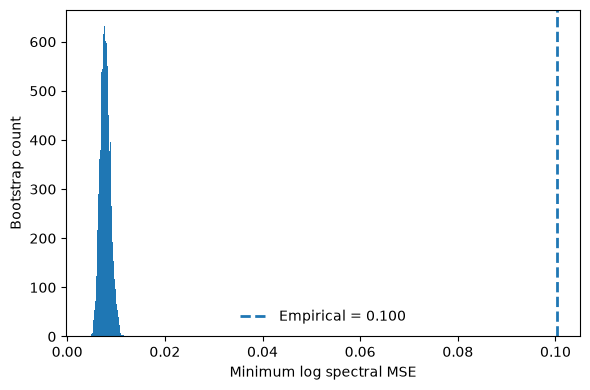

In [22]:
# ============================================================
# PLOT BOOTSTRAP GOODNESS-OF-FIT DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 4)
)

ax.hist(
    boot["min_log_spectral_mse"],
    bins=50
)

ax.axvline(
    OBS_T,
    linestyle="--",
    linewidth=2,
    label=f"Empirical = {OBS_T:.3f}"
)

ax.set_xlabel(
    "Minimum log spectral MSE"
)

ax.set_ylabel(
    "Bootstrap count"
)

ax.legend(
    frameon=False
)

plt.tight_layout()

fig.savefig(
    OUT / "bootstrap_smooth_field_goodness_of_fit.png",
    dpi=300
)

fig.savefig(
    OUT / "bootstrap_smooth_field_goodness_of_fit.pdf"
)

plt.show()

## 5. Explicit mesh-based spatial-smoothing null


In [18]:
# ============================================================
# PUBLICATION-GRADE MESH-BASED SPATIAL-SMOOTHNESS NULL
#
# White random cortical maps
#   -> intrinsic heat diffusion on fsaverage5 mesh
#   -> projection onto the SAME eigenmodes as empirical data
#   -> modal energy spectrum
#
# Crucially:
#   * smoothing operator is constructed from mesh geometry
#   * it does NOT use the 120 Pang eigenmodes
#   * left and right hemispheres treated separately
#   * spectra averaged across hemispheres
#
# Explicit mesh validation uses N_MAPS = 300 per FWHM level.
# The inferential null distribution is generated separately by
# the 10,000-realization parametric bootstrap above.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.sparse.linalg import expm_multiply

BASE = Path.home() / "eigenmode_fingerprints"

SURF = BASE / "pang_surfaces" / "fsaverage5"
EIG  = BASE / "modes" / "fsaverage5"
GRP  = BASE / "pang_out" / "group"

OUT = BASE / "pang_out" / "mesh_spatial_smoothing_null"
OUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

N_MAPS = 300
# Explicit mesh simulation validates the analytical smooth-field null.
# Inferential testing uses the separate 10,000-realization
# parametric bootstrap; no 10,000-map mesh run is required.
BATCH_SIZE = 100
SEED = 20260831

# We don't need 0.5-mm spacing for the expensive first pass.
# Start at 2-mm spacing.
FWHM_GRID = np.array([

    0, 10, 20, 25, 30, 35, 40, 50

], dtype=float)

rng = np.random.default_rng(SEED)

print("N random maps:", N_MAPS)
print("FWHM grid:", FWHM_GRID)

N random maps: 300
FWHM grid: [ 0. 10. 20. 25. 30. 35. 40. 50.]


In [12]:
# ============================================================
# MESH GEOMETRY
# ============================================================

def load_surface(path):
    g = nib.load(str(path))
    coords = np.asarray(g.darrays[0].data, dtype=np.float64)
    faces = np.asarray(g.darrays[1].data, dtype=np.int64)
    return coords, faces


def cotangent_laplacian(coords, faces):
    """
    Construct cotangent stiffness matrix C and lumped vertex
    mass vector M from triangular surface mesh.

    Generalized heat equation:
        M du/dt = -C u

    We convert this to a symmetric normalized operator:
        Lsym = M^{-1/2} C M^{-1/2}

    Surface coordinates are in mm, so eigenvalues of the
    resulting operator have approximate units mm^-2.
    """

    n = coords.shape[0]

    i = faces[:, 0]
    j = faces[:, 1]
    k = faces[:, 2]

    vi = coords[i]
    vj = coords[j]
    vk = coords[k]

    # Edge vectors at each triangle vertex
    e_ij = vj - vi
    e_ik = vk - vi

    e_ji = vi - vj
    e_jk = vk - vj

    e_ki = vi - vk
    e_kj = vj - vk

    # Twice triangle area
    cross = np.cross(e_ij, e_ik)
    double_area = np.linalg.norm(cross, axis=1)

    # Avoid pathological zero-area triangles
    double_area = np.maximum(double_area, 1e-15)

    # Cotangents of angles at i, j, k
    cot_i = (
        np.einsum("ij,ij->i", e_ij, e_ik)
        / double_area
    )

    cot_j = (
        np.einsum("ij,ij->i", e_ji, e_jk)
        / double_area
    )

    cot_k = (
        np.einsum("ij,ij->i", e_ki, e_kj)
        / double_area
    )

    # Edge weights:
    # edge jk gets cot(angle i)/2, etc.
    rows = np.concatenate([
        j, k,
        i, k,
        i, j
    ])

    cols = np.concatenate([
        k, j,
        k, i,
        j, i
    ])

    vals = 0.5 * np.concatenate([
        cot_i, cot_i,
        cot_j, cot_j,
        cot_k, cot_k
    ])

    W = sparse.coo_matrix(
        (vals, (rows, cols)),
        shape=(n, n)
    ).tocsr()

    # Cotangent stiffness matrix
    degree = np.asarray(W.sum(axis=1)).ravel()

    C = sparse.diags(degree) - W

    # Triangle areas
    area = double_area / 2.0

    # Lumped barycentric vertex area: each triangle gives 1/3
    mass = np.zeros(n, dtype=np.float64)

    np.add.at(mass, i, area / 3.0)
    np.add.at(mass, j, area / 3.0)
    np.add.at(mass, k, area / 3.0)

    mass = np.maximum(mass, 1e-15)

    invsqrt_m = 1.0 / np.sqrt(mass)

    D = sparse.diags(invsqrt_m)

    # Symmetric normalized cotangent Laplacian
    Lsym = D @ C @ D

    return Lsym.tocsr(), mass

In [7]:
# ============================================================
# LOAD SURFACES + MODES
# ============================================================

coordsL, facesL = load_surface(
    SURF / "lh.white.surf.gii"
)

coordsR, facesR = load_surface(
    SURF / "rh.white.surf.gii"
)

phiL = np.load(EIG / "phi_L.npy")
phiR = np.load(EIG / "phi_R.npy")

lamL = np.load(EIG / "lam_L.npy")
lamR = np.load(EIG / "lam_R.npy")

print("Building cotangent Laplacians...")

LsymL, massL = cotangent_laplacian(
    coordsL, facesL
)

LsymR, massR = cotangent_laplacian(
    coordsR, facesR
)

print("Done.")

print("L:", LsymL.shape, "nnz =", LsymL.nnz)
print("R:", LsymR.shape, "nnz =", LsymR.nnz)

Building cotangent Laplacians...
Done.
L: (10242, 10242) nnz = 71682
R: (10242, 10242) nnz = 71682


In [13]:
# ============================================================
# HEAT-KERNEL SURFACE SMOOTHING
# ============================================================

def fwhm_to_tau(fwhm):
    return (
        float(fwhm)**2
        / (16.0 * np.log(2.0))
    )


def heat_smooth(X, Lsym, mass, tau):
    """
    X shape: vertices x maps

    Physical heat equation:
        M du/dt = -C u

    With v = M^(1/2) u:
        dv/dt = -Lsym v

    Therefore:
        u(t) =
          M^(-1/2) exp(-tau Lsym) M^(1/2) u(0)
    """

    if tau == 0:
        return X.copy()

    sqrt_m = np.sqrt(mass)[:, None]
    invsqrt_m = 1.0 / sqrt_m

    V0 = sqrt_m * X

    Vt = expm_multiply(
        -tau * Lsym,
        V0
    )

    return invsqrt_m * Vt

In [14]:
# ============================================================
# GENERATE MESH-SMOOTHED RANDOM-FIELD SPECTRA
# ============================================================

def spatial_null_spectrum(
    phi,
    Lsym,
    mass,
    fwhm,
    n_maps,
    batch_size,
    rng
):
    """
    Two-pass calculation.

    Pass 1:
      estimate vertex-wise variance after smoothing.

    Pass 2:
      generate an independent random set,
      apply same smoothing,
      divide by estimated vertex SD,
      project with empirical phi.T @ X,
      accumulate mean A^2.

    This avoids storing all maps simultaneously.
    """

    tau = fwhm_to_tau(fwhm)

    V = phi.shape[0]
    K = phi.shape[1]

    # ----------------------------------------
    # PASS 1 — estimate vertex variance
    # ----------------------------------------

    sumsq_v = np.zeros(V, dtype=np.float64)
    total = 0

    while total < n_maps:

        b = min(
            batch_size,
            n_maps - total
        )

        X = rng.standard_normal(
            (V, b)
        )

        Xs = heat_smooth(
            X,
            Lsym,
            mass,
            tau
        )

        sumsq_v += np.sum(
            Xs**2,
            axis=1
        )

        total += b

    sd_v = np.sqrt(
        sumsq_v / n_maps
    )

    sd_v[sd_v < 1e-12] = 1.0

    # ----------------------------------------
    # PASS 2 — new random maps, standardized
    # exactly like empirical vertex timecourses
    # ----------------------------------------

    sum_energy = np.zeros(
        K,
        dtype=np.float64
    )

    total = 0

    while total < n_maps:

        b = min(
            batch_size,
            n_maps - total
        )

        X = rng.standard_normal(
            (V, b)
        )

        Xs = heat_smooth(
            X,
            Lsym,
            mass,
            tau
        )

        # vertex-wise variance normalization
        Xz = Xs / sd_v[:, None]

        # EXACT empirical projection convention
        A = phi.T @ Xz

        sum_energy += np.sum(
            A**2,
            axis=1
        )

        total += b

    E = sum_energy / n_maps

    return E

In [15]:
# ============================================================
# RUN SMOOTHING GRID
# ============================================================

rows = []
spectra = {}

for fwhm in FWHM_GRID:

    print(f"\nFWHM = {fwhm:.1f} mm")

    EL = spatial_null_spectrum(
        phiL,
        LsymL,
        massL,
        fwhm,
        N_MAPS,
        BATCH_SIZE,
        rng
    )

    ER = spatial_null_spectrum(
        phiR,
        LsymR,
        massR,
        fwhm,
        N_MAPS,
        BATCH_SIZE,
        rng
    )

    # Match original L/R averaging conceptually
    E = 0.5 * (EL + ER)

    spectra[fwhm] = E

print("\nAll smoothing levels completed.")


FWHM = 0.0 mm

FWHM = 10.0 mm

FWHM = 20.0 mm

FWHM = 25.0 mm

FWHM = 30.0 mm

FWHM = 35.0 mm

FWHM = 40.0 mm

FWHM = 50.0 mm

All smoothing levels completed.


In [16]:
# ============================================================
# SAVE MESH NULL SPECTRA PERMANENTLY
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path.home() / "eigenmode_fingerprints"
OUT = BASE / "pang_out" / "mesh_spatial_smoothing_null"
OUT.mkdir(parents=True, exist_ok=True)

rows = []

for fwhm, E in sorted(spectra.items()):
    for k, energy in enumerate(np.asarray(E, float)):
        rows.append({
            "fwhm_mm": float(fwhm),
            "mode_k": int(k),
            "E": float(energy),
        })

mesh_spectra_df = pd.DataFrame(rows)

savefile = OUT / "mesh_smoothing_spectra.csv"
mesh_spectra_df.to_csv(savefile, index=False)

print("Saved:", savefile)
print("Rows:", len(mesh_spectra_df))
print("FWHM levels:", sorted(mesh_spectra_df["fwhm_mm"].unique()))

Saved: /home/whinzen/eigenmode_fingerprints/pang_out/mesh_spatial_smoothing_null/mesh_smoothing_spectra.csv
Rows: 960
FWHM levels: [np.float64(0.0), np.float64(10.0), np.float64(20.0), np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(50.0)]


In [17]:
# ============================================================
# EMPIRICAL vs MESH-BASED NULL
# ============================================================

grp = pd.read_csv(
    GRP / "energy_spectrum_group.csv"
)

mode = grp["mode_k"].to_numpy(int)
lam = grp["lam"].to_numpy(float)
Eemp = grp["Emean"].to_numpy(float)

keep = mode >= 1

mode1 = mode[keep]
lam1 = lam[keep]
Eemp1 = Eemp[keep]


def normalize(E):
    E = np.asarray(E, float)
    return E / E.sum()


def log_mse(E1, E2):
    eps = 1e-15

    p1 = normalize(E1)
    p2 = normalize(E2)

    return np.mean(
        (
            np.log10(p1 + eps)
            - np.log10(p2 + eps)
        )**2
    )


comparison = []

for fwhm, E in spectra.items():

    d = log_mse(
        Eemp1,
        E[1:]
    )

    comparison.append({
        "fwhm_mm": fwhm,
        "log_mse": d
    })

comparison = pd.DataFrame(
    comparison
)

best_row = comparison.loc[
    comparison["log_mse"].idxmin()
]

BEST_FWHM = float(
    best_row["fwhm_mm"]
)

BEST_MSE = float(
    best_row["log_mse"]
)

print("\nMESH-BASED SMOOTH-FIELD NULL")
print("----------------------------")

print(
    f"Best FWHM = {BEST_FWHM:.1f} mm"
)

print(
    f"Best log-MSE = {BEST_MSE:.6f}"
)

display(comparison)


MESH-BASED SMOOTH-FIELD NULL
----------------------------
Best FWHM = 30.0 mm
Best log-MSE = 0.101881


,fwhm_mm,log_mse
0,0.0,0.349671
1,10.0,0.315137
2,20.0,0.212547
3,25.0,0.149644
4,30.0,0.101881
5,35.0,0.104628
6,40.0,0.167403
7,50.0,0.409880


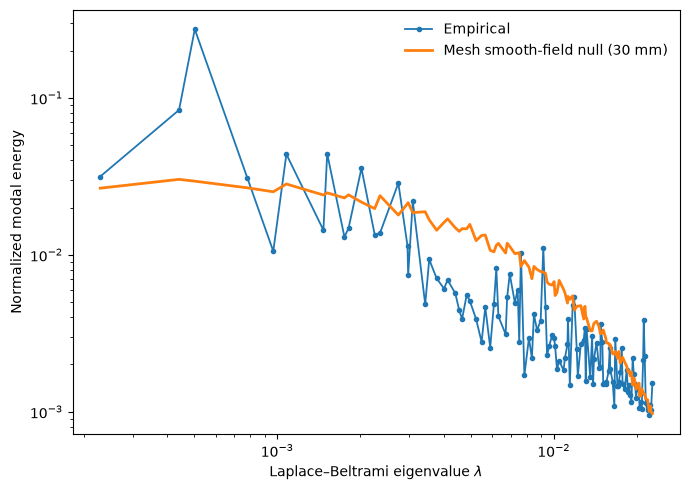

In [42]:
# ============================================================
# FIGURE
# ============================================================

Ebest = spectra[BEST_FWHM][1:]

fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.plot(
    lam1,
    normalize(Eemp1),
    marker="o",
    markersize=3,
    lw=1.3,
    label="Empirical"
)

ax.plot(
    lam1,
    normalize(Ebest),
    lw=2,
    label=f"Mesh smooth-field null ({BEST_FWHM:.0f} mm)"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    r"Laplace–Beltrami eigenvalue $\lambda$"
)

ax.set_ylabel(
    "Normalized modal energy"
)

ax.legend(frameon=False)

plt.tight_layout()

fig.savefig(
    OUT / "empirical_vs_mesh_smoothing_null.png",
    dpi=300
)

fig.savefig(
    OUT / "empirical_vs_mesh_smoothing_null.pdf"
)

plt.show()

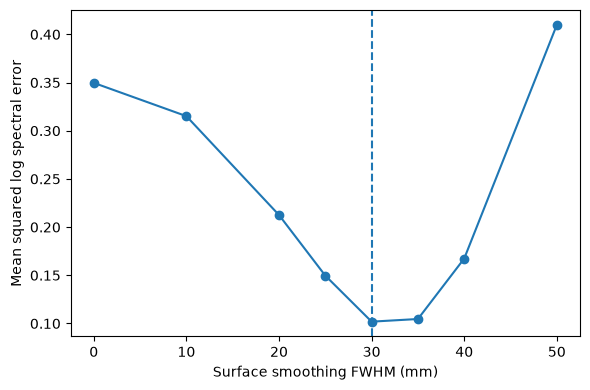

In [43]:
fig, ax = plt.subplots(
    figsize=(6, 4)
)

ax.plot(
    comparison["fwhm_mm"],
    comparison["log_mse"],
    marker="o"
)

ax.axvline(
    BEST_FWHM,
    linestyle="--"
)

ax.set_xlabel(
    "Surface smoothing FWHM (mm)"
)

ax.set_ylabel(
    "Mean squared log spectral error"
)

plt.tight_layout()
plt.show()

## 6. Participant-level and fitting-range robustness


In [44]:
# ============================================================
# PARTICIPANT-LEVEL COMPETING SPECTRAL MODELS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy import stats

BASE = Path.home() / "eigenmode_fingerprints"
GRP = BASE / "pang_out" / "group"
OUT = BASE / "pang_out" / "spectral_model_comparison"
OUT.mkdir(parents=True, exist_ok=True)

sub = pd.read_csv(
    GRP / "energy_spectrum_subject.csv"
)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

def stretched_log(lam, c, b, gamma):
    return c - b * lam**gamma


def cutoff_log(lam, c, alpha, inv_lambda_c):
    return (
        c
        + alpha * np.log(lam)
        - inv_lambda_c * lam
    )


def information_criteria(y, yhat, k):

    n = len(y)

    rss = np.sum(
        (y - yhat)**2
    )

    aic = (
        n * np.log(rss / n)
        + 2 * k
    )

    aicc = (
        aic
        + (2 * k * (k + 1))
        / (n - k - 1)
    )

    bic = (
        n * np.log(rss / n)
        + k * np.log(n)
    )

    r2 = (
        1
        - rss
        / np.sum(
            (y - np.mean(y))**2
        )
    )

    return rss, r2, aic, aicc, bic


def fit_models_one_subject(d):

    d = d[
        (d["mode_k"] >= 1)
        & (d["mode_k"] <= 60)
        & (d["lam"] > 0)
        & (d["Emean"] > 0)
    ].copy()

    lam = d["lam"].to_numpy(float)
    E = d["Emean"].to_numpy(float)

    x = np.log(lam)
    y = np.log(E)

    n = len(y)

    results = []

    # ========================================================
    # 1. POWER LAW
    # ========================================================

    X = np.column_stack([
        np.ones(n),
        x
    ])

    beta, *_ = np.linalg.lstsq(
        X, y, rcond=None
    )

    c, alpha = beta

    yhat = X @ beta

    rss, r2, aic, aicc, bic = (
        information_criteria(
            y, yhat, k=2
        )
    )

    results.append({
        "model": "Power law",
        "alpha": alpha,
        "b": np.nan,
        "gamma": np.nan,
        "lambda_c": np.nan,
        "R2_log": r2,
        "AIC": aic,
        "AICc": aicc,
        "BIC": bic
    })

    # ========================================================
    # 2. EXPONENTIAL
    # ========================================================

    X = np.column_stack([
        np.ones(n),
        lam
    ])

    beta, *_ = np.linalg.lstsq(
        X, y, rcond=None
    )

    c = beta[0]
    b = -beta[1]

    yhat = X @ beta

    rss, r2, aic, aicc, bic = (
        information_criteria(
            y, yhat, k=2
        )
    )

    results.append({
        "model": "Exponential",
        "alpha": np.nan,
        "b": b,
        "gamma": 1.0,
        "lambda_c": np.nan,
        "R2_log": r2,
        "AIC": aic,
        "AICc": aicc,
        "BIC": bic
    })

    # ========================================================
    # 3. STRETCHED EXPONENTIAL
    # ========================================================

    try:

        pars, _ = curve_fit(
            stretched_log,
            lam,
            y,
            p0=[
                np.max(y),
                100.0,
                0.5
            ],
            bounds=(
                [-np.inf, 0.0, 0.05],
                [ np.inf, np.inf, 5.0]
            ),
            maxfev=100000
        )

        c, b, gamma = pars

        yhat = stretched_log(
            lam, *pars
        )

        rss, r2, aic, aicc, bic = (
            information_criteria(
                y, yhat, k=3
            )
        )

        results.append({
            "model": "Stretched exponential",
            "alpha": np.nan,
            "b": b,
            "gamma": gamma,
            "lambda_c": np.nan,
            "R2_log": r2,
            "AIC": aic,
            "AICc": aicc,
            "BIC": bic
        })

    except Exception:
        pass

    # ========================================================
    # 4. POWER LAW + CUTOFF
    # ========================================================

    try:

        pars, _ = curve_fit(
            cutoff_log,
            lam,
            y,
            p0=[
                np.mean(y),
                -1.0,
                10.0
            ],
            bounds=(
                [-np.inf, -10.0, 0.0],
                [ np.inf,  10.0, np.inf]
            ),
            maxfev=100000
        )

        c, alpha_cut, inv_lc = pars

        lambda_c = (
            np.inf
            if inv_lc <= 1e-12
            else 1.0 / inv_lc
        )

        yhat = cutoff_log(
            lam, *pars
        )

        rss, r2, aic, aicc, bic = (
            information_criteria(
                y, yhat, k=3
            )
        )

        results.append({
            "model": "Power law + cutoff",
            "alpha": alpha_cut,
            "b": np.nan,
            "gamma": np.nan,
            "lambda_c": lambda_c,
            "R2_log": r2,
            "AIC": aic,
            "AICc": aicc,
            "BIC": bic
        })

    except Exception:
        pass

    return pd.DataFrame(results)


# ------------------------------------------------------------
# Fit all 49 participants
# ------------------------------------------------------------

all_results = []

for subject, dsub in sub.groupby("subject"):

    r = fit_models_one_subject(
        dsub
    )

    r.insert(
        0,
        "subject",
        subject
    )

    all_results.append(r)

subject_models = pd.concat(
    all_results,
    ignore_index=True
)

# ------------------------------------------------------------
# Within-subject model comparisons
# ------------------------------------------------------------

subject_models[
    "delta_AICc"
] = (
    subject_models["AICc"]
    - subject_models.groupby(
        "subject"
    )["AICc"].transform("min")
)

subject_models[
    "delta_BIC"
] = (
    subject_models["BIC"]
    - subject_models.groupby(
        "subject"
    )["BIC"].transform("min")
)

subject_models[
    "Akaike_weight"
] = (
    subject_models.groupby(
        "subject"
    )["delta_AICc"]
    .transform(
        lambda x:
        np.exp(-0.5*x)
        / np.exp(-0.5*x).sum()
    )
)

subject_models.to_csv(
    OUT / "participant_spectral_model_comparison.csv",
    index=False
)

print(
    "Participants:",
    subject_models["subject"].nunique()
)

print(
    "Fits:",
    len(subject_models)
)

# ------------------------------------------------------------
# Winning model counts
# ------------------------------------------------------------

winners = (
    subject_models.loc[
        subject_models.groupby(
            "subject"
        )["AICc"].idxmin()
    ]
)

winner_counts = (
    winners["model"]
    .value_counts()
)

print("\nAICc WINNING MODEL COUNTS")
print("-------------------------")
print(winner_counts)

# ------------------------------------------------------------
# Mean Akaike support
# ------------------------------------------------------------

print("\nMEAN AKAIKE WEIGHT")
print("------------------")

display(
    subject_models.groupby("model")[
        "Akaike_weight"
    ].agg(
        ["mean", "median", "std"]
    ).sort_values(
        "mean",
        ascending=False
    )
)

# ------------------------------------------------------------
# Direct key comparison:
# exponential minus power law
#
# Positive = POWER LAW preferred
# ------------------------------------------------------------

wide = subject_models.pivot(
    index="subject",
    columns="model",
    values="AICc"
)

wide[
    "delta_exp_minus_PL"
] = (
    wide["Exponential"]
    - wide["Power law"]
)

delta = wide[
    "delta_exp_minus_PL"
].dropna()

print("\nEXPONENTIAL vs POWER LAW")
print("------------------------")

print(
    "Mean ΔAICc (Exp - PL):",
    delta.mean()
)

print(
    "Median ΔAICc:",
    delta.median()
)

print(
    "Participants favouring PL:",
    np.sum(delta > 0),
    "/",
    len(delta)
)

print(
    "Participants strongly favouring PL "
    "(ΔAICc > 10):",
    np.sum(delta > 10),
    "/",
    len(delta)
)

# Wilcoxon paired test
wil = stats.wilcoxon(
    delta
)

print(
    "Wilcoxon signed-rank:",
    wil
)

# Save
wide.to_csv(
    OUT / "participant_powerlaw_vs_exponential.csv"
)

Participants: 49
Fits: 196

AICc WINNING MODEL COUNTS
-------------------------
model
Power law                47
Stretched exponential     2
Name: count, dtype: int64

MEAN AKAIKE WEIGHT
------------------


,mean,median,std
model,,,
Power law,0.493791,0.501815,0.060246
Stretched exponential,0.301920,0.296214,0.053389
Power law + cutoff,0.203319,0.201206,0.010718
Exponential,0.000970,0.000246,0.001885



EXPONENTIAL vs POWER LAW
------------------------
Mean ΔAICc (Exp - PL): 17.425213825970236
Median ΔAICc: 15.369805435628535
Participants favouring PL: 49 / 49
Participants strongly favouring PL (ΔAICc > 10): 44 / 49
Wilcoxon signed-rank: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(3.552713678800501e-15))


In [1]:
# ============================================================
# ROBUSTNESS OF SPECTRAL MODEL COMPARISON TO FITTING RANGE
#
# Ranges:
#   k = 1–40
#   k = 1–60   [PRIMARY]
#   k = 10–80
#
# Fits:
#   1. Power law
#   2. Exponential
#   3. Stretched exponential
#   4. Power law + exponential cutoff
#
# Outputs:
#   - group-level model comparison by range
#   - participant-level model comparison by range
#   - participant winner counts
#   - PL vs exponential paired robustness statistics
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy import stats

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = Path.home() / "eigenmode_fingerprints"
GRP = BASE / "pang_out" / "group"
OUT = BASE / "pang_out" / "spectral_model_comparison"
OUT.mkdir(parents=True, exist_ok=True)

GROUP_FILE = GRP / "energy_spectrum_group.csv"
SUBJECT_FILE = GRP / "energy_spectrum_subject.csv"

group_df = pd.read_csv(GROUP_FILE)
subject_df = pd.read_csv(SUBJECT_FILE)

RANGES = [
    (1, 40),
    (1, 60),
    (10, 80),
]

# ============================================================
# MODEL DEFINITIONS
# ============================================================

def stretched_log(lam, c, b, gamma):
    """
    log(E) = c - b * lambda^gamma
    """
    return c - b * lam**gamma


def cutoff_log(lam, c, alpha, inv_lambda_c):
    """
    log(E) = c + alpha*log(lambda) - lambda/lambda_c

    Parameterized using inv_lambda_c = 1/lambda_c
    for numerical stability.
    """
    return (
        c
        + alpha * np.log(lam)
        - inv_lambda_c * lam
    )


def information_criteria(y, yhat, k):
    """
    Gaussian-error information criteria in fitted log-energy space.

    k = number of fitted model parameters.
    """

    n = len(y)

    rss = np.sum((y - yhat)**2)

    # Protect against pathological numerical zero
    rss = max(rss, np.finfo(float).tiny)

    aic = (
        n * np.log(rss / n)
        + 2 * k
    )

    aicc = (
        aic
        + (2 * k * (k + 1))
        / (n - k - 1)
    )

    bic = (
        n * np.log(rss / n)
        + k * np.log(n)
    )

    tss = np.sum(
        (y - np.mean(y))**2
    )

    r2 = (
        1 - rss / tss
        if tss > 0
        else np.nan
    )

    return {
        "RSS": rss,
        "R2_log": r2,
        "AIC": aic,
        "AICc": aicc,
        "BIC": bic,
    }


# ============================================================
# FIT ALL FOUR MODELS TO ONE SPECTRUM
# ============================================================

def fit_models(d, kmin, kmax):

    d = d[
        (d["mode_k"] >= kmin)
        & (d["mode_k"] <= kmax)
        & (d["lam"] > 0)
        & (d["Emean"] > 0)
    ].copy()

    lam = d["lam"].to_numpy(float)
    E = d["Emean"].to_numpy(float)

    x = np.log(lam)
    y = np.log(E)

    n = len(y)

    results = []

    # --------------------------------------------------------
    # 1. POWER LAW
    #
    # log(E) = c + alpha log(lambda)
    # --------------------------------------------------------

    X = np.column_stack([
        np.ones(n),
        x
    ])

    beta, *_ = np.linalg.lstsq(
        X, y, rcond=None
    )

    c, alpha = beta
    yhat = X @ beta

    ic = information_criteria(
        y, yhat, k=2
    )

    results.append({
        "model": "Power law",
        "alpha": alpha,
        "b": np.nan,
        "gamma": np.nan,
        "lambda_c": np.nan,
        **ic
    })

    # --------------------------------------------------------
    # 2. SIMPLE EXPONENTIAL
    #
    # log(E) = c - b lambda
    # --------------------------------------------------------

    X = np.column_stack([
        np.ones(n),
        lam
    ])

    beta, *_ = np.linalg.lstsq(
        X, y, rcond=None
    )

    c = beta[0]
    b = -beta[1]
    yhat = X @ beta

    ic = information_criteria(
        y, yhat, k=2
    )

    results.append({
        "model": "Exponential",
        "alpha": np.nan,
        "b": b,
        "gamma": 1.0,
        "lambda_c": np.nan,
        **ic
    })

    # --------------------------------------------------------
    # 3. STRETCHED EXPONENTIAL
    #
    # log(E) = c - b lambda^gamma
    # --------------------------------------------------------

    try:

        pars, _ = curve_fit(
            stretched_log,
            lam,
            y,
            p0=[
                np.max(y),
                100.0,
                0.5
            ],
            bounds=(
                [-np.inf, 0.0, 0.05],
                [ np.inf, np.inf, 5.0]
            ),
            maxfev=100000
        )

        c, b, gamma = pars

        yhat = stretched_log(
            lam, *pars
        )

        ic = information_criteria(
            y, yhat, k=3
        )

        results.append({
            "model": "Stretched exponential",
            "alpha": np.nan,
            "b": b,
            "gamma": gamma,
            "lambda_c": np.nan,
            **ic
        })

    except Exception as exc:

        print(
            f"WARNING: stretched exponential failed "
            f"for k={kmin}-{kmax}: {exc}"
        )

    # --------------------------------------------------------
    # 4. POWER LAW + EXPONENTIAL CUTOFF
    #
    # log(E) =
    # c + alpha log(lambda) - lambda/lambda_c
    # --------------------------------------------------------

    try:

        pars, _ = curve_fit(
            cutoff_log,
            lam,
            y,
            p0=[
                np.mean(y),
                -1.0,
                10.0
            ],
            bounds=(
                [-np.inf, -10.0, 0.0],
                [ np.inf,  10.0, np.inf]
            ),
            maxfev=100000
        )

        c, alpha_cut, inv_lc = pars

        lambda_c = (
            np.inf
            if inv_lc <= 1e-12
            else 1.0 / inv_lc
        )

        yhat = cutoff_log(
            lam, *pars
        )

        ic = information_criteria(
            y, yhat, k=3
        )

        results.append({
            "model": "Power law + cutoff",
            "alpha": alpha_cut,
            "b": np.nan,
            "gamma": np.nan,
            "lambda_c": lambda_c,
            **ic
        })

    except Exception as exc:

        print(
            f"WARNING: cutoff power law failed "
            f"for k={kmin}-{kmax}: {exc}"
        )

    return pd.DataFrame(results)


# ============================================================
# GROUP-LEVEL ANALYSIS
# ============================================================

group_results = []

for kmin, kmax in RANGES:

    r = fit_models(
        group_df,
        kmin,
        kmax
    )

    r.insert(0, "kmin", kmin)
    r.insert(1, "kmax", kmax)

    # Delta IC within this fitting range
    r["delta_AICc"] = (
        r["AICc"] - r["AICc"].min()
    )

    r["delta_BIC"] = (
        r["BIC"] - r["BIC"].min()
    )

    weights = np.exp(
        -0.5 * r["delta_AICc"]
    )

    r["Akaike_weight"] = (
        weights / weights.sum()
    )

    group_results.append(r)

group_results = pd.concat(
    group_results,
    ignore_index=True
)

group_results.to_csv(
    OUT / "group_model_comparison_by_range.csv",
    index=False
)


# ============================================================
# PARTICIPANT-LEVEL ANALYSIS
# ============================================================

participant_results = []

for kmin, kmax in RANGES:

    for subject, dsub in subject_df.groupby("subject"):

        r = fit_models(
            dsub,
            kmin,
            kmax
        )

        r.insert(0, "subject", subject)
        r.insert(1, "kmin", kmin)
        r.insert(2, "kmax", kmax)

        # Delta IC within participant AND range
        r["delta_AICc"] = (
            r["AICc"] - r["AICc"].min()
        )

        r["delta_BIC"] = (
            r["BIC"] - r["BIC"].min()
        )

        weights = np.exp(
            -0.5 * r["delta_AICc"]
        )

        r["Akaike_weight"] = (
            weights / weights.sum()
        )

        participant_results.append(r)

participant_results = pd.concat(
    participant_results,
    ignore_index=True
)

participant_results.to_csv(
    OUT / "participant_model_comparison_by_range.csv",
    index=False
)


# ============================================================
# GROUP-LEVEL SUMMARY
# ============================================================

print("\n")
print("=" * 76)
print("GROUP-LEVEL MODEL COMPARISON")
print("=" * 76)

for kmin, kmax in RANGES:

    d = group_results[
        (group_results["kmin"] == kmin)
        & (group_results["kmax"] == kmax)
    ].copy()

    print(
        f"\nMODE RANGE k={kmin}-{kmax}"
    )
    print("-" * 60)

    display(
        d[
            [
                "model",
                "R2_log",
                "AICc",
                "delta_AICc",
                "Akaike_weight",
                "BIC",
                "delta_BIC",
            ]
        ].sort_values("AICc")
    )


# ============================================================
# PARTICIPANT WINNER COUNTS
# ============================================================

winner_rows = []

for kmin, kmax in RANGES:

    d = participant_results[
        (participant_results["kmin"] == kmin)
        & (participant_results["kmax"] == kmax)
    ]

    winners = d.loc[
        d.groupby("subject")[
            "AICc"
        ].idxmin()
    ]

    counts = (
        winners["model"]
        .value_counts()
    )

    for model in [
        "Power law",
        "Stretched exponential",
        "Power law + cutoff",
        "Exponential",
    ]:

        winner_rows.append({
            "range": f"{kmin}-{kmax}",
            "model": model,
            "n_winners": int(
                counts.get(model, 0)
            ),
            "percent": (
                100
                * counts.get(model, 0)
                / winners["subject"].nunique()
            )
        })

winner_table = pd.DataFrame(
    winner_rows
)

winner_table.to_csv(
    OUT / "participant_winner_counts_by_range.csv",
    index=False
)

print("\n")
print("=" * 76)
print("PARTICIPANT AICc WINNERS")
print("=" * 76)

display(
    winner_table.pivot(
        index="model",
        columns="range",
        values="n_winners"
    )
)


# ============================================================
# MEAN AKAIKE WEIGHTS BY RANGE
# ============================================================

weight_summary = (
    participant_results
    .groupby(
        ["kmin", "kmax", "model"]
    )["Akaike_weight"]
    .agg(
        mean="mean",
        median="median",
        sd="std"
    )
    .reset_index()
)

weight_summary.to_csv(
    OUT / "participant_akaike_weights_by_range.csv",
    index=False
)

print("\n")
print("=" * 76)
print("MEAN PARTICIPANT AKAIKE WEIGHTS")
print("=" * 76)

display(
    weight_summary
)


# ============================================================
# KEY TEST:
# EXPONENTIAL vs POWER LAW
#
# Positive ΔAICc = power law preferred
# ============================================================

robustness_rows = []

for kmin, kmax in RANGES:

    d = participant_results[
        (participant_results["kmin"] == kmin)
        & (participant_results["kmax"] == kmax)
    ]

    wide = d.pivot(
        index="subject",
        columns="model",
        values="AICc"
    )

    delta = (
        wide["Exponential"]
        - wide["Power law"]
    ).dropna()

    wil = stats.wilcoxon(
        delta,
        alternative="two-sided"
    )

    robustness_rows.append({

        "range": f"{kmin}-{kmax}",

        "n": len(delta),

        "mean_delta_AICc_Exp_minus_PL":
            delta.mean(),

        "median_delta_AICc_Exp_minus_PL":
            delta.median(),

        "min_delta_AICc_Exp_minus_PL":
            delta.min(),

        "max_delta_AICc_Exp_minus_PL":
            delta.max(),

        "n_favour_PL":
            int(np.sum(delta > 0)),

        "pct_favour_PL":
            100 * np.mean(delta > 0),

        "n_strong_PL_delta_gt_10":
            int(np.sum(delta > 10)),

        "pct_strong_PL_delta_gt_10":
            100 * np.mean(delta > 10),

        "wilcoxon_W":
            wil.statistic,

        "wilcoxon_p":
            wil.pvalue,
    })

robustness = pd.DataFrame(
    robustness_rows
)

robustness.to_csv(
    OUT / "powerlaw_vs_exponential_range_robustness.csv",
    index=False
)

print("\n")
print("=" * 76)
print("POWER LAW vs EXPONENTIAL: RANGE ROBUSTNESS")
print("Positive ΔAICc = power law preferred")
print("=" * 76)

display(robustness)


# ============================================================
# COMPACT SUPPLEMENTARY TABLE
# ============================================================

# Group ΔAICc values in wide form
group_delta = (
    group_results[
        ["kmin", "kmax", "model", "delta_AICc"]
    ]
    .assign(
        range=lambda x:
        x["kmin"].astype(str)
        + "-"
        + x["kmax"].astype(str)
    )
    .pivot(
        index="range",
        columns="model",
        values="delta_AICc"
    )
    .reset_index()
)

# PL winner counts
pl_winners = (
    winner_table[
        winner_table["model"] == "Power law"
    ][
        ["range", "n_winners"]
    ]
    .rename(
        columns={
            "n_winners":
                "PL_AICc_winner_n"
        }
    )
)

supp_table = (
    robustness
    .merge(
        pl_winners,
        on="range"
    )
    .merge(
        group_delta,
        on="range"
    )
)

supp_table.to_csv(
    OUT / "supplementary_range_robustness_summary.csv",
    index=False
)

print("\n")
print("=" * 76)
print("COMPACT ROBUSTNESS SUMMARY")
print("=" * 76)

display(supp_table)

print("\nSaved all outputs to:")
print(OUT)



GROUP-LEVEL MODEL COMPARISON

MODE RANGE k=1-40
------------------------------------------------------------


,model,R2_log,AICc,delta_AICc,Akaike_weight,BIC,delta_BIC
0,Power law,0.700008,-43.147514,0.000000,0.427410,-40.094079,0.000000
2,Stretched exponential,0.714219,-42.746438,0.401075,0.349746,-38.346467,1.747613
3,Power law + cutoff,0.706782,-41.718789,1.428724,0.209219,-37.318818,2.775262
1,Exponential,0.643602,-36.255828,6.891685,0.013625,-33.202394,6.891685



MODE RANGE k=1-60
------------------------------------------------------------


,model,R2_log,AICc,delta_AICc,Akaike_weight,BIC,delta_BIC
4,Power law,0.736715,-73.047891,0.000000,0.505268,-69.069728,0.000000
6,Stretched exponential,0.741747,-71.987717,1.060174,0.297377,-66.133255,2.936473
7,Power law + cutoff,0.738192,-71.167400,1.880491,0.197323,-65.312938,3.756791
5,Exponential,0.636265,-53.656562,19.391329,0.000031,-49.678399,19.391329



MODE RANGE k=10-80
------------------------------------------------------------


...



POWER LAW vs EXPONENTIAL: RANGE ROBUSTNESS
Positive ΔAICc = power law preferred


,range,n,mean_delta_AICc_Exp_minus_PL,median_delta_AICc_Exp_minus_PL,min_delta_AICc_Exp_minus_PL,max_delta_AICc_Exp_minus_PL,n_favour_PL,pct_favour_PL,n_strong_PL_delta_gt_10,pct_strong_PL_delta_gt_10,wilcoxon_W,wilcoxon_p
0,1-40,49,6.216698,4.921597,0.841021,20.441261,49,100.0,6,12.244898,0.0,3.552714e-15
1,1-60,49,17.425214,15.369805,7.441589,42.516693,49,100.0,44,89.795918,0.0,3.552714e-15
2,10-80,49,14.362245,13.996857,10.014759,21.142686,49,100.0,49,100.000000,0.0,3.552714e-15




COMPACT ROBUSTNESS SUMMARY


,range,n,mean_delta_AICc_Exp_minus_PL,median_delta_AICc_Exp_minus_PL,min_delta_AICc_Exp_minus_PL,max_delta_AICc_Exp_minus_PL,n_favour_PL,pct_favour_PL,n_strong_PL_delta_gt_10,pct_strong_PL_delta_gt_10,wilcoxon_W,wilcoxon_p,PL_AICc_winner_n,Exponential,Power law,Power law + cutoff,Stretched exponential
0,1-40,49,6.216698,4.921597,0.841021,20.441261,49,100.0,6,12.244898,0.0,3.552714e-15,38,6.891685,0.0,1.428724,0.401075
1,1-60,49,17.425214,15.369805,7.441589,42.516693,49,100.0,44,89.795918,0.0,3.552714e-15,47,19.391329,0.0,1.880491,1.060174
2,10-80,49,14.362245,13.996857,10.014759,21.142686,49,100.0,49,100.000000,0.0,3.552714e-15,49,15.688778,0.0,2.181738,2.798342



Saved all outputs to:
/home/whinzen/eigenmode_fingerprints/pang_out/spectral_model_comparison


## 7. Publication export


Saved in-memory mesh spectra to: /home/whinzen/eigenmode_fingerprints/pang_out/mesh_spatial_smoothing_null/mesh_smoothing_spectra.csv
Best explicit mesh null: 30.0 mm, log-MSE=0.101881
Best analytical null: 31.0 mm, log-MSE=0.100237


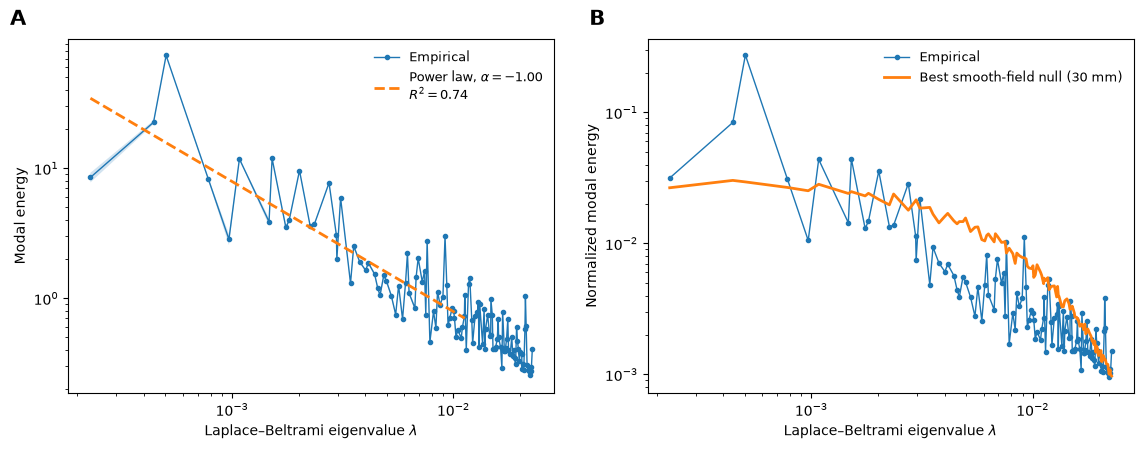

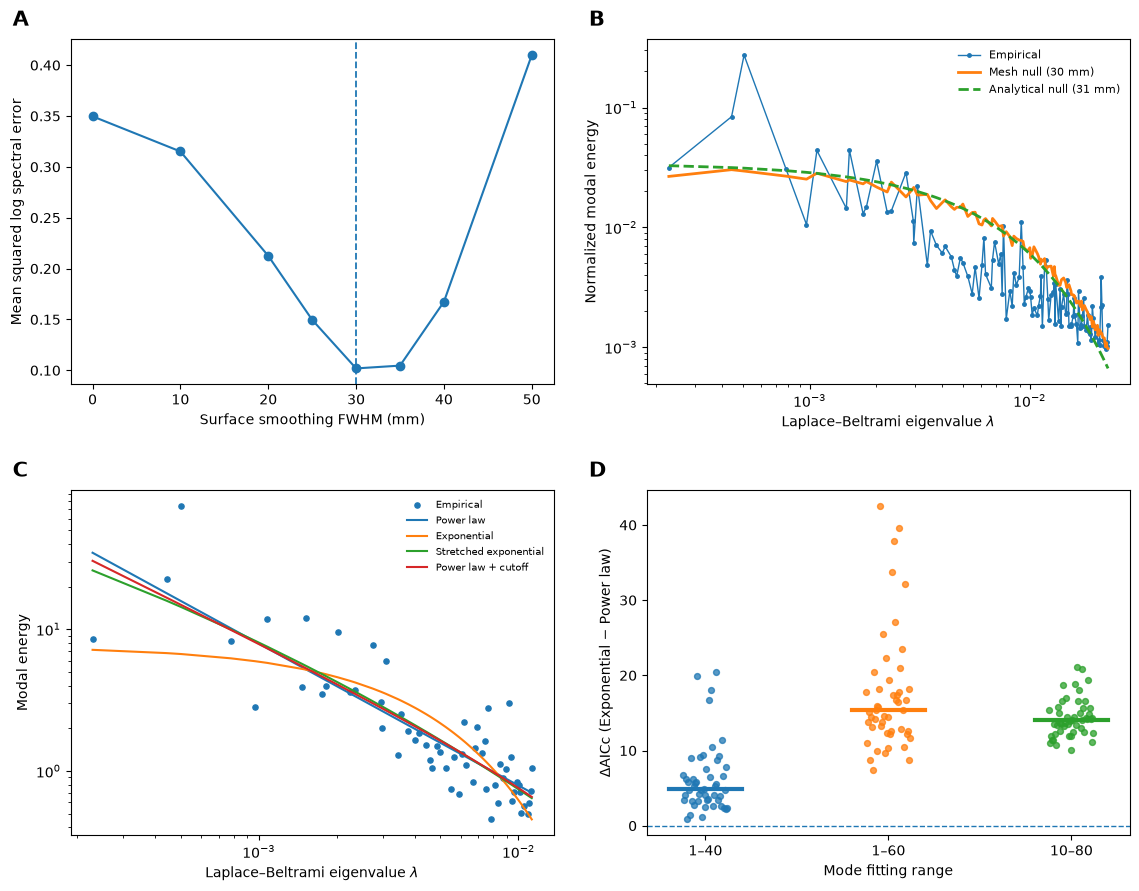



SUPPLEMENTARY TABLE 1
Candidate spectral models, primary range k=1-60


,Model,R2_log,AICc,Delta_AICc,Akaike_weight,BIC,Delta_BIC,alpha,b,gamma,lambda_c
4,Power law,0.737,-73.05,0.00,0.505,-69.07,0.00,-1.001,NaN,NaN,NaN
6,Stretched exponential,0.742,-71.99,1.06,0.297,-66.13,2.94,NaN,16.528,0.138,NaN
7,Power law + cutoff,0.738,-71.17,1.88,0.197,-65.31,3.76,-0.903,NaN,NaN,0.0343
5,Exponential,0.636,-53.66,19.39,0.000,-49.68,19.39,NaN,249.932,1.000,NaN




SUPPLEMENTARY TABLE 2
Robustness to fitted mode range


,Mode range,Group Delta_AICc Exp-PL,Median participant Delta_AICc,PL preferred to Exp,Delta_AICc > 10,PL overall AICc winner
0,1-40,6.89,4.92,49/49,6/49,38/49
1,1-60,19.39,15.37,49/49,44/49,47/49
2,10-80,15.69,14.00,49/49,49/49,49/49




EXPORT COMPLETE

Main Figure 2:
/home/whinzen/eigenmode_fingerprints/pang_out/paper_figures/spatial_scaling_revision/figure2_revised_spatial_scaling.png
/home/whinzen/eigenmode_fingerprints/pang_out/paper_figures/spatial_scaling_revision/figure2_revised_spatial_scaling.pdf

Supplementary Figure:
/home/whinzen/eigenmode_fingerprints/pang_out/paper_figures/spatial_scaling_revision/supplementary_spatial_scaling_robustness.png
/home/whinzen/eigenmode_fingerprints/pang_out/paper_figures/spatial_scaling_revision/supplementary_spatial_scaling_robustness.pdf

Tables:
/home/whinzen/eigenmode_fingerprints/pang_out/paper_figures/spatial_scaling_revision/supplementary_table_1_candidate_models.csv
/home/whinzen/eigenmode_fingerprints/pang_out/paper_figures/spatial_scaling_revision/supplementary_table_2_range_robustness.csv

Permanent mesh-spectrum files:
/home/whinzen/eigenmode_fingerprints/pang_out/mesh_spatial_smoothing_null/mesh_smoothing_spectra.csv
/home/whinzen/eigenmode_fingerprints/pang_o

In [19]:
# ============================================================
# FINAL PUBLICATION EXPORT
#
# Creates:
#   Figure 2 A-B
#   Supplementary Figure A-D
#   Supplementary Table 1: candidate spectral models
#   Supplementary Table 2: fitting-range robustness
#
# IMPORTANT:
#   When this notebook is run top-to-bottom, the mesh-null section
#   above creates `spectra` and permanently saves the spectra CSV.
#   On later runs, this export cell can load the saved CSV directly.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE = Path.home() / "eigenmode_fingerprints"

GRP = BASE / "pang_out" / "group"

NULL_ANALYTIC = (
    BASE / "pang_out" / "spatial_smoothing_null"
)

NULL_MESH = (
    BASE / "pang_out" / "mesh_spatial_smoothing_null"
)

MODEL_DIR = (
    BASE / "pang_out" / "spectral_model_comparison"
)

PUB = (
    BASE / "pang_out" / "paper_figures" / "spatial_scaling_revision"
)

PUB.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# CHECK MESH NULL
# ------------------------------------------------------------

MESH_SPECTRA_FILE = (
    NULL_MESH / "mesh_smoothing_spectra.csv"
)

MESH_COMPARISON_FILE = (
    NULL_MESH / "mesh_smoothing_comparison.csv"
)

if "spectra" in globals():

    # Save explicit mesh spectra permanently so we never
    # need to recompute them just for plotting.

    mesh_rows = []

    for fwhm, Earr in sorted(
        spectra.items(),
        key=lambda z: float(z[0])
    ):

        for k, val in enumerate(
            np.asarray(Earr, float)
        ):

            mesh_rows.append({
                "fwhm_mm": float(fwhm),
                "mode_k": int(k),
                "E": float(val)
            })

    mesh_long = pd.DataFrame(
        mesh_rows
    )

    mesh_long.to_csv(
        MESH_SPECTRA_FILE,
        index=False
    )

    # Also save the coarse FWHM comparison if available
    if "comparison" in globals():

        comparison.to_csv(
            MESH_COMPARISON_FILE,
            index=False
        )

    print(
        "Saved in-memory mesh spectra to:",
        MESH_SPECTRA_FILE
    )

elif MESH_SPECTRA_FILE.exists():

    mesh_long = pd.read_csv(
        MESH_SPECTRA_FILE
    )

    print(
        "Loaded saved mesh spectra:",
        MESH_SPECTRA_FILE
    )

else:

    raise RuntimeError(
        "\nExplicit mesh spectra are not in memory and have "
        "not yet been saved to disk.\n\n"
        "Please run the mesh-based spatial-smoothing section above once, then rerun "
        "this cell. This cell will save them permanently."
    )


# ============================================================
# LOAD EMPIRICAL SPECTRUM
# ============================================================

emp = pd.read_csv(
    GRP / "energy_spectrum_group.csv"
)

mode = emp["mode_k"].to_numpy(int)
lam_all = emp["lam"].to_numpy(float)
E_all = emp["Emean"].to_numpy(float)
SEM_all = emp["Esem"].to_numpy(float)

keep = (
    (mode >= 1)
    & (lam_all > 0)
    & (E_all > 0)
)

mode1 = mode[keep]
lam1 = lam_all[keep]
Eemp = E_all[keep]
SEMemp = SEM_all[keep]

# primary fit
fitmask = (
    (mode1 >= 1)
    & (mode1 <= 60)
)

fit = linregress(
    np.log10(lam1[fitmask]),
    np.log10(Eemp[fitmask])
)

alpha = fit.slope
r2 = fit.rvalue**2

Efit = (
    10**fit.intercept
    * lam1[fitmask]**fit.slope
)


def normalize(E):
    E = np.asarray(E, float)
    return E / np.sum(E)


# ============================================================
# LOAD BEST EXPLICIT MESH NULL
# ============================================================

if MESH_COMPARISON_FILE.exists():

    mesh_comp = pd.read_csv(
        MESH_COMPARISON_FILE
    )

else:

    # reconstruct comparison from known spectra

    rows = []

    for fwhm, d in mesh_long.groupby(
        "fwhm_mm"
    ):

        d = d.sort_values("mode_k")

        Enull = (
            d.loc[
                d["mode_k"] >= 1,
                "E"
            ].to_numpy(float)
        )

        p1 = normalize(Eemp)
        p2 = normalize(Enull)

        mse = np.mean(
            (
                np.log10(p1 + 1e-15)
                - np.log10(p2 + 1e-15)
            )**2
        )

        rows.append({
            "fwhm_mm": fwhm,
            "log_mse": mse
        })

    mesh_comp = pd.DataFrame(rows)

    mesh_comp.to_csv(
        MESH_COMPARISON_FILE,
        index=False
    )


best_mesh_row = mesh_comp.loc[
    mesh_comp["log_mse"].idxmin()
]

BEST_MESH_FWHM = float(
    best_mesh_row["fwhm_mm"]
)

BEST_MESH_MSE = float(
    best_mesh_row["log_mse"]
)

mesh_best = (
    mesh_long[
        mesh_long["fwhm_mm"]
        == BEST_MESH_FWHM
    ]
    .sort_values("mode_k")
)

Emesh = (
    mesh_best.loc[
        mesh_best["mode_k"] >= 1,
        "E"
    ]
    .to_numpy(float)
)

print(
    f"Best explicit mesh null: "
    f"{BEST_MESH_FWHM:.1f} mm, "
    f"log-MSE={BEST_MESH_MSE:.6f}"
)


# ============================================================
# LOAD ANALYTICAL NULL
# ============================================================

analytic_grid_file = (
    NULL_ANALYTIC
    / "expected_smoothing_spectra_grid.csv"
)

smooth = pd.read_csv(
    analytic_grid_file
)

best_analytic = smooth.loc[
    smooth[
        "spectral_log_mse_1_119"
    ].idxmin()
]

BEST_ANALYTIC_FWHM = float(
    best_analytic["fwhm_mm"]
)

BEST_ANALYTIC_MSE = float(
    best_analytic[
        "spectral_log_mse_1_119"
    ]
)

tau_analytic = (
    BEST_ANALYTIC_FWHM**2
    / (16.0 * np.log(2.0))
)

Eanalytic = np.exp(
    -2.0 * tau_analytic * lam1
)

print(
    f"Best analytical null: "
    f"{BEST_ANALYTIC_FWHM:.1f} mm, "
    f"log-MSE={BEST_ANALYTIC_MSE:.6f}"
)


# ============================================================
# LOAD MODEL COMPARISON RESULTS
# ============================================================

group_models = pd.read_csv(
    MODEL_DIR
    / "group_model_comparison_by_range.csv"
)

participant_models = pd.read_csv(
    MODEL_DIR
    / "participant_model_comparison_by_range.csv"
)

robustness = pd.read_csv(
    MODEL_DIR
    / "powerlaw_vs_exponential_range_robustness.csv"
)

winner_counts = pd.read_csv(
    MODEL_DIR
    / "participant_winner_counts_by_range.csv"
)


# ============================================================
# FIGURE 2 — MAIN TEXT
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.6)
)

# ------------------------------------------------------------
# PANEL A — empirical spectrum + primary power-law fit
# ------------------------------------------------------------

ax = axes[0]

ax.plot(
    lam1,
    Eemp,
    marker="o",
    markersize=3,
    linewidth=1.0,
    label="Empirical"
)

# SEM envelope
lower = np.maximum(
    Eemp - SEMemp,
    1e-15
)

upper = Eemp + SEMemp

ax.fill_between(
    lam1,
    lower,
    upper,
    alpha=0.2
)

ax.plot(
    lam1[fitmask],
    Efit,
    linestyle="--",
    linewidth=2,
    label=(
        rf"Power law, $\alpha={alpha:.2f}$"
        "\n"
        rf"$R^2={r2:.2f}$"
    )
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    r"Laplace–Beltrami eigenvalue $\lambda$"
)

ax.set_ylabel(
    "Modal energy"
)

ax.legend(
    frameon=False,
    fontsize=9
)

ax.text(
    -0.12,
    1.04,
    "A",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold"
)


# ------------------------------------------------------------
# PANEL B — empirical vs explicit spatial-smoothness null
# ------------------------------------------------------------

ax = axes[1]

ax.plot(
    lam1,
    normalize(Eemp),
    marker="o",
    markersize=3,
    linewidth=1.0,
    label="Empirical"
)

ax.plot(
    lam1,
    normalize(Emesh),
    linewidth=2,
    label=(
        f"Best smooth-field null "
        f"({BEST_MESH_FWHM:.0f} mm)"
    )
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    r"Laplace–Beltrami eigenvalue $\lambda$"
)

ax.set_ylabel(
    "Normalized modal energy"
)

ax.legend(
    frameon=False,
    fontsize=9
)

ax.text(
    -0.12,
    1.04,
    "B",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold"
)

fig.tight_layout(
    w_pad=2.2
)

fig.savefig(
    PUB / "figure2_revised_spatial_scaling.png",
    dpi=400,
    bbox_inches="tight"
)

fig.savefig(
    PUB / "figure2_revised_spatial_scaling.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SUPPLEMENTARY FIGURE — FOUR PANELS
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.5, 9.0)
)

# ------------------------------------------------------------
# A — mesh-null mismatch as a function of smoothing scale
# ------------------------------------------------------------

ax = axes[0, 0]

ax.plot(
    mesh_comp["fwhm_mm"],
    mesh_comp["log_mse"],
    marker="o",
    linewidth=1.5
)

ax.axvline(
    BEST_MESH_FWHM,
    linestyle="--",
    linewidth=1.3
)

ax.set_xlabel(
    "Surface smoothing FWHM (mm)"
)

ax.set_ylabel(
    "Mean squared log spectral error"
)

ax.text(
    -0.12,
    1.04,
    "A",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold"
)


# ------------------------------------------------------------
# B — empirical + mesh null + analytical null
# ------------------------------------------------------------

ax = axes[0, 1]

ax.plot(
    lam1,
    normalize(Eemp),
    marker="o",
    markersize=2.5,
    linewidth=1,
    label="Empirical"
)

ax.plot(
    lam1,
    normalize(Emesh),
    linewidth=2,
    label=f"Mesh null ({BEST_MESH_FWHM:.0f} mm)"
)

ax.plot(
    lam1,
    normalize(Eanalytic),
    linestyle="--",
    linewidth=2,
    label=f"Analytical null ({BEST_ANALYTIC_FWHM:.0f} mm)"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    r"Laplace–Beltrami eigenvalue $\lambda$"
)

ax.set_ylabel(
    "Normalized modal energy"
)

ax.legend(
    frameon=False,
    fontsize=8
)

ax.text(
    -0.12,
    1.04,
    "B",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold"
)


# ------------------------------------------------------------
# C — competing spectral models, primary k=1-60
# ------------------------------------------------------------

ax = axes[1, 0]

primary = group_models[
    (group_models["kmin"] == 1)
    & (group_models["kmax"] == 60)
].copy()

lam60 = lam1[fitmask]
E60 = Eemp[fitmask]

ax.scatter(
    lam60,
    E60,
    s=14,
    label="Empirical"
)

# Generate model predictions directly from saved parameters
for _, row in primary.iterrows():

    name = row["model"]

    if name == "Power law":

        # refit normalization c only, with saved alpha
        a = float(row["alpha"])

        c = np.mean(
            np.log(E60)
            - a * np.log(lam60)
        )

        pred = np.exp(c) * lam60**a


    elif name == "Exponential":

        b = float(row["b"])

        c = np.mean(
            np.log(E60)
            + b * lam60
        )

        pred = np.exp(
            c - b * lam60
        )


    elif name == "Stretched exponential":

        b = float(row["b"])
        gamma = float(row["gamma"])

        c = np.mean(
            np.log(E60)
            + b * lam60**gamma
        )

        pred = np.exp(
            c - b * lam60**gamma
        )


    elif name == "Power law + cutoff":

        a = float(row["alpha"])
        lc = float(row["lambda_c"])

        c = np.mean(
            np.log(E60)
            - a * np.log(lam60)
            + lam60 / lc
        )

        pred = (
            np.exp(c)
            * lam60**a
            * np.exp(-lam60 / lc)
        )

    else:
        continue

    order = np.argsort(lam60)

    ax.plot(
        lam60[order],
        pred[order],
        linewidth=1.5,
        label=name
    )


ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    r"Laplace–Beltrami eigenvalue $\lambda$"
)

ax.set_ylabel(
    "Modal energy"
)

ax.legend(
    frameon=False,
    fontsize=7.5
)

ax.text(
    -0.12,
    1.04,
    "C",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold"
)


# ------------------------------------------------------------
# D — participant ΔAICc robustness
# ------------------------------------------------------------

ax = axes[1, 1]

range_order = [
    (1, 40),
    (1, 60),
    (10, 80)
]

range_labels = [
    "1–40",
    "1–60",
    "10–80"
]

for xpos, (kmin, kmax) in enumerate(
    range_order
):

    d = participant_models[
        (participant_models["kmin"] == kmin)
        & (participant_models["kmax"] == kmax)
    ]

    wide = d.pivot(
        index="subject",
        columns="model",
        values="AICc"
    )

    delta = (
        wide["Exponential"]
        - wide["Power law"]
    ).to_numpy(float)

    # deterministic horizontal jitter purely for visibility
    jitter = np.linspace(
        -0.12,
        0.12,
        len(delta)
    )

    ax.scatter(
        np.full(len(delta), xpos)
        + jitter,
        delta,
        s=18,
        alpha=0.75
    )

    ax.plot(
        [xpos - 0.20, xpos + 0.20],
        [np.median(delta)] * 2,
        linewidth=3
    )


ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_xticks(
    range(len(range_labels))
)

ax.set_xticklabels(
    range_labels
)

ax.set_xlabel(
    "Mode fitting range"
)

ax.set_ylabel(
    r"$\Delta$AICc (Exponential − Power law)"
)

ax.text(
    -0.12,
    1.04,
    "D",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold"
)


fig.tight_layout(
    h_pad=2.3,
    w_pad=2.2
)

fig.savefig(
    PUB / "supplementary_spatial_scaling_robustness.png",
    dpi=400,
    bbox_inches="tight"
)

fig.savefig(
    PUB / "supplementary_spatial_scaling_robustness.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SUPPLEMENTARY TABLE 1
# PRIMARY CANDIDATE SPECTRAL MODELS, k=1-60
# ============================================================

table1 = primary.copy()

table1 = table1[
    [
        "model",
        "R2_log",
        "AICc",
        "delta_AICc",
        "Akaike_weight",
        "BIC",
        "delta_BIC",
        "alpha",
        "b",
        "gamma",
        "lambda_c"
    ]
].sort_values(
    "AICc"
)

table1 = table1.rename(
    columns={
        "model": "Model",
        "R2_log": "R2_log",
        "AICc": "AICc",
        "delta_AICc": "Delta_AICc",
        "Akaike_weight": "Akaike_weight",
        "BIC": "BIC",
        "delta_BIC": "Delta_BIC",
        "alpha": "alpha",
        "b": "b",
        "gamma": "gamma",
        "lambda_c": "lambda_c"
    }
)

table1.to_csv(
    PUB / "supplementary_table_1_candidate_models.csv",
    index=False
)

print("\n")
print("=" * 80)
print("SUPPLEMENTARY TABLE 1")
print("Candidate spectral models, primary range k=1-60")
print("=" * 80)

display(
    table1.round({
        "R2_log": 3,
        "AICc": 2,
        "Delta_AICc": 2,
        "Akaike_weight": 3,
        "BIC": 2,
        "Delta_BIC": 2,
        "alpha": 3,
        "b": 3,
        "gamma": 3,
        "lambda_c": 4
    })
)


# ============================================================
# SUPPLEMENTARY TABLE 2
# FITTING-RANGE ROBUSTNESS
# ============================================================

winner_lookup = (
    winner_counts[
        winner_counts["model"]
        == "Power law"
    ]
    .set_index("range")[
        "n_winners"
    ]
    .to_dict()
)

table2_rows = []

for _, row in robustness.iterrows():

    rg = str(row["range"])

    # handle pandas potentially interpreting range strangely
    if rg.endswith(".0"):
        rg = rg[:-2]

    table2_rows.append({
        "Mode range": rg,
        "Group Delta_AICc Exp-PL":
            np.nan,  # filled below
        "Median participant Delta_AICc":
            row["median_delta_AICc_Exp_minus_PL"],
        "PL preferred to Exp":
            f"{int(row['n_favour_PL'])}/{int(row['n'])}",
        "Delta_AICc > 10":
            f"{int(row['n_strong_PL_delta_gt_10'])}/{int(row['n'])}",
        "PL overall AICc winner":
            f"{int(winner_lookup.get(rg, np.nan))}/{int(row['n'])}"
            if rg in winner_lookup else ""
    })


table2 = pd.DataFrame(
    table2_rows
)

# Add group Exp-vs-PL ΔAICc directly
for i, (kmin, kmax) in enumerate(
    range_order
):

    d = group_models[
        (group_models["kmin"] == kmin)
        & (group_models["kmax"] == kmax)
    ]

    aicc_exp = float(
        d.loc[
            d["model"] == "Exponential",
            "AICc"
        ].iloc[0]
    )

    aicc_pl = float(
        d.loc[
            d["model"] == "Power law",
            "AICc"
        ].iloc[0]
    )

    table2.loc[
        i,
        "Group Delta_AICc Exp-PL"
    ] = (
        aicc_exp - aicc_pl
    )


table2.to_csv(
    PUB / "supplementary_table_2_range_robustness.csv",
    index=False
)

print("\n")
print("=" * 80)
print("SUPPLEMENTARY TABLE 2")
print("Robustness to fitted mode range")
print("=" * 80)

display(
    table2.round({
        "Group Delta_AICc Exp-PL": 2,
        "Median participant Delta_AICc": 2
    })
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("EXPORT COMPLETE")
print("=" * 80)

print("\nMain Figure 2:")
print(
    PUB / "figure2_revised_spatial_scaling.png"
)
print(
    PUB / "figure2_revised_spatial_scaling.pdf"
)

print("\nSupplementary Figure:")
print(
    PUB / "supplementary_spatial_scaling_robustness.png"
)
print(
    PUB / "supplementary_spatial_scaling_robustness.pdf"
)

print("\nTables:")
print(
    PUB / "supplementary_table_1_candidate_models.csv"
)
print(
    PUB / "supplementary_table_2_range_robustness.csv"
)

print("\nPermanent mesh-spectrum files:")
print(MESH_SPECTRA_FILE)
print(MESH_COMPARISON_FILE)

In [20]:
# ============================================================
# FINAL SUPPLEMENTARY TABLES
#
# Table 1:
#   Candidate spectral models, primary range k=1-60
#
# Table 2:
#   Robustness to fitted eigenmode range
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

BASE = Path.home() / "eigenmode_fingerprints"

MODEL_DIR = (
    BASE / "pang_out" / "spectral_model_comparison"
)

OUT = (
    BASE / "pang_out" / "paper_figures" / "spatial_scaling_revision"
)
OUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD SAVED RESULTS
# ------------------------------------------------------------

group_models = pd.read_csv(
    MODEL_DIR / "group_model_comparison_by_range.csv"
)

participant_models = pd.read_csv(
    MODEL_DIR / "participant_model_comparison_by_range.csv"
)

robustness = pd.read_csv(
    MODEL_DIR / "powerlaw_vs_exponential_range_robustness.csv"
)

winner_counts = pd.read_csv(
    MODEL_DIR / "participant_winner_counts_by_range.csv"
)


# ============================================================
# SUPPLEMENTARY TABLE 1
# Candidate spectral models, primary range k=1-60
# ============================================================

t1 = group_models[
    (group_models["kmin"] == 1)
    & (group_models["kmax"] == 60)
].copy()

# Sort by AICc support
t1 = t1.sort_values("AICc").reset_index(drop=True)

def key_parameter_string(row):
    model = row["model"]

    if model == "Power law":
        return rf"α = {row['alpha']:.3f}"

    elif model == "Stretched exponential":
        return (
            rf"b = {row['b']:.2f}, "
            rf"γ = {row['gamma']:.3f}"
        )

    elif model == "Power law + cutoff":
        return (
            rf"α = {row['alpha']:.3f}, "
            rf"λc = {row['lambda_c']:.4f}"
        )

    elif model == "Exponential":
        return rf"b = {row['b']:.2f}"

    else:
        return ""


table1 = pd.DataFrame({
    "Model": t1["model"],
    "R²_log": t1["R2_log"].map(lambda x: f"{x:.3f}"),
    "AICc": t1["AICc"].map(lambda x: f"{x:.2f}"),
    "ΔAICc": t1["delta_AICc"].map(lambda x: f"{x:.2f}"),
    "Akaike weight": t1["Akaike_weight"].map(
        lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"
    ),
    "BIC": t1["BIC"].map(lambda x: f"{x:.2f}"),
    "ΔBIC": t1["delta_BIC"].map(lambda x: f"{x:.2f}"),
    "Key parameters": t1.apply(key_parameter_string, axis=1)
})

print("\n" + "="*90)
print("SUPPLEMENTARY TABLE 1")
print("Comparison of candidate models for cortical eigenmode spectral decay")
print("="*90)

display(table1)

table1.to_csv(
    OUT / "supplementary_table_1_candidate_models_formatted.csv",
    index=False
)


# ============================================================
# SUPPLEMENTARY TABLE 2
# Robustness to fitted eigenmode range
# ============================================================

range_order = [
    (1, 40),
    (1, 60),
    (10, 80)
]

rows = []

for kmin, kmax in range_order:

    # -------------------------
    # group ΔAICc Exp - PL
    # -------------------------
    gd = group_models[
        (group_models["kmin"] == kmin)
        & (group_models["kmax"] == kmax)
    ]

    aicc_exp = float(
        gd.loc[
            gd["model"] == "Exponential",
            "AICc"
        ].iloc[0]
    )

    aicc_pl = float(
        gd.loc[
            gd["model"] == "Power law",
            "AICc"
        ].iloc[0]
    )

    group_delta = aicc_exp - aicc_pl

    # -------------------------
    # participant ΔAICc Exp - PL
    # -------------------------
    pd_part = participant_models[
        (participant_models["kmin"] == kmin)
        & (participant_models["kmax"] == kmax)
    ]

    wide = pd_part.pivot(
        index="subject",
        columns="model",
        values="AICc"
    )

    delta = (
        wide["Exponential"]
        - wide["Power law"]
    )

    n = len(delta)

    n_pl_better = int(
        (delta > 0).sum()
    )

    n_strong = int(
        (delta > 10).sum()
    )

    median_delta = float(
        np.median(delta)
    )

    # -------------------------
    # overall PL winner count
    # -------------------------
    winners = (
        pd_part.loc[
            pd_part.groupby("subject")["AICc"].idxmin()
        ]
    )

    n_pl_winner = int(
        (winners["model"] == "Power law").sum()
    )

    rows.append({
        "Mode range": f"{kmin}–{kmax}",
        "Group ΔAICc Exp–PL": f"{group_delta:.2f}",
        "Median participant ΔAICc Exp–PL": f"{median_delta:.2f}",
        "PL preferred to Exp": f"{n_pl_better}/{n}",
        "ΔAICc > 10": f"{n_strong}/{n}",
        "PL overall winner": f"{n_pl_winner}/{n}"
    })


table2 = pd.DataFrame(rows)

print("\n" + "="*90)
print("SUPPLEMENTARY TABLE 2")
print("Robustness of spectral model comparison to fitted eigenmode range")
print("="*90)

display(table2)

table2.to_csv(
    OUT / "supplementary_table_2_range_robustness_formatted.csv",
    index=False
)


# ============================================================
# OPTIONAL: SAVE BOTH TABLES IN ONE EXCEL FILE
# ============================================================

excel_file = (
    OUT / "supplementary_spatial_scaling_tables.xlsx"
)

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    table1.to_excel(
        writer,
        sheet_name="Table 1 - Models",
        index=False
    )

    table2.to_excel(
        writer,
        sheet_name="Table 2 - Robustness",
        index=False
    )

print("\nSaved:")
print(
    OUT / "supplementary_table_1_candidate_models_formatted.csv"
)
print(
    OUT / "supplementary_table_2_range_robustness_formatted.csv"
)
print(excel_file)


SUPPLEMENTARY TABLE 1
Comparison of candidate models for cortical eigenmode spectral decay


,Model,R²_log,AICc,ΔAICc,Akaike weight,BIC,ΔBIC,Key parameters
0,Power law,0.737,-73.05,0.00,0.505,-69.07,0.00,α = -1.001
1,Stretched exponential,0.742,-71.99,1.06,0.297,-66.13,2.94,"b = 16.53, γ = 0.138"
2,Power law + cutoff,0.738,-71.17,1.88,0.197,-65.31,3.76,"α = -0.903, λc = 0.0343"
3,Exponential,0.636,-53.66,19.39,<0.001,-49.68,19.39,b = 249.93



SUPPLEMENTARY TABLE 2
Robustness of spectral model comparison to fitted eigenmode range


,Mode range,Group ΔAICc Exp–PL,Median participant ΔAICc Exp–PL,PL preferred to Exp,ΔAICc > 10,PL overall winner
0,1–40,6.89,4.92,49/49,6/49,38/49
1,1–60,19.39,15.37,49/49,44/49,47/49
2,10–80,15.69,14.00,49/49,49/49,49/49


ModuleNotFoundError: No module named 'openpyxl'